# Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Import the dataset

In [2]:
#reading dataset from file
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
train_data = pd.read_csv("C:/Users/Brayn/Downloads/cell2celltrain.csv")
test_data = pd.read_csv("C:/Users/Brayn/Downloads/cell2cellholdout.csv")
train_data.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


# DATA CLEANING

In [3]:
# information about the train data
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  str    
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  float64
 14  T

In [4]:
# information about the test data
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 20000 non-null  int64  
 1   Churn                      0 non-null      float64
 2   MonthlyRevenue             19940 non-null  float64
 3   MonthlyMinutes             19940 non-null  float64
 4   TotalRecurringCharge       19940 non-null  float64
 5   DirectorAssistedCalls      19940 non-null  float64
 6   OverageMinutes             19940 non-null  float64
 7   RoamingCalls               19940 non-null  float64
 8   PercChangeMinutes          19865 non-null  float64
 9   PercChangeRevenues         19865 non-null  float64
 10  DroppedCalls               20000 non-null  float64
 11  BlockedCalls               20000 non-null  float64
 12  UnansweredCalls            20000 non-null  float64
 13  CustomerCareCalls          20000 non-null  float64
 14  T

The testing data doesn't have Churn values, so this holdout data will only be used for making predictions. Data cleaning on it will only be done after model development and training

In [5]:
# dropping customer ID
train_data = train_data.drop(columns='CustomerID')

In [6]:
# checking for duplicates
print(f'train data(duplicates): {train_data.duplicated().sum()}')
print(f'test data(duplicates): {test_data.duplicated().sum()}')

train data(duplicates): 0
test data(duplicates): 0


In [7]:
#checking for null values (missing data)
print(f'train data (missing values): {train_data.isnull().sum()}')
print(f'\ntest data (missing values): \n{test_data.isnull().sum()}')

train data (missing values): Churn                          0
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
PercChangeMinutes            367
PercChangeRevenues           367
DroppedCalls                   0
BlockedCalls                   0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
DroppedBlockedCalls            0
CallForwardingCalls            0
CallWaitingCalls               0
MonthsInService                0
UniqueSubs                     0
ActiveSubs                     0
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
AgeHH1        

In [8]:
# HandsetPrice value counts (not numeric)
train_data['HandsetPrice'].value_counts()

HandsetPrice
Unknown    28982
30          7328
150         4115
130         2105
80          1960
10          1928
60          1776
200         1266
100         1235
40           249
400           46
250           20
300           13
180           10
500            8
240            6
Name: count, dtype: int64

In [9]:
# Convert 'HandsetPrice' values to numeric
train_data['HandsetPrice'] = pd.to_numeric(test_data['HandsetPrice'], errors='coerce')
test_data['HandsetPrice'] = pd.to_numeric(test_data['HandsetPrice'], errors='coerce')

# Check how many NaNs were introduced
print(f'train data: {train_data['HandsetPrice'].isna().sum()}')
print(f'test data: {test_data['HandsetPrice'].isna().sum()}')

train data: 42314
test data: 11267


In [10]:
# Handling missing data
# Since Churn has 20000 missing values, its advisable to drop them since Churn is the target variable.
test_data = test_data.drop(columns='Churn')

# dropping the HandsetPrice column as it has to many missing values (more than 50%)
train_data = train_data.drop(columns='HandsetPrice')
test_data = test_data.drop(columns='HandsetPrice')

# Handling other missing values from other variables by imputing with mean if its numeric and mode if its categoric
variables = ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 
             'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'AgeHH1', 'AgeHH2', 'ServiceArea']

# To avoid any leakages, we will be imputing with values from the training data
for feature in variables:
    if train_data[feature].dtype in ['float64', 'int64']:
        mean_val = train_data[feature].mean()
        train_data[feature] = train_data[feature].fillna(mean_val)
        if feature in test_data.columns:
            test_data[feature] = test_data[feature].fillna(mean_val)
    else:
        mode_val = train_data[feature].mode()[0]
        train_data[feature] = train_data[feature].fillna(mode_val)
        if feature in test_data.columns:
            test_data[feature] = test_data[feature].fillna(mode_val)

In [11]:
# fixing the CreditRating Column
credit_order = {
    '1-Highest': 1,
    '2-High': 2,
    '3-Good': 3,
    '4-Medium': 4,
    '5-Low': 5,
    '6-VeryLow': 6,
    '7-Lowest': 7
}

train_data['CreditRating'] = train_data['CreditRating'].map(credit_order)
test_data['CreditRating'] = test_data['CreditRating'].map(credit_order)

In [12]:
# Missing data re-check
print(f'train data(misiing values): {train_data.isnull().sum().sum()}')
print(f'\ntest data(misiing values): {test_data.isnull().sum().sum()}')

train data(misiing values): 0

test data(misiing values): 0


In [13]:
# checking train data info
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Churn                      51047 non-null  str    
 1   MonthlyRevenue             51047 non-null  float64
 2   MonthlyMinutes             51047 non-null  float64
 3   TotalRecurringCharge       51047 non-null  float64
 4   DirectorAssistedCalls      51047 non-null  float64
 5   OverageMinutes             51047 non-null  float64
 6   RoamingCalls               51047 non-null  float64
 7   PercChangeMinutes          51047 non-null  float64
 8   PercChangeRevenues         51047 non-null  float64
 9   DroppedCalls               51047 non-null  float64
 10  BlockedCalls               51047 non-null  float64
 11  UnansweredCalls            51047 non-null  float64
 12  CustomerCareCalls          51047 non-null  float64
 13  ThreewayCalls              51047 non-null  float64
 14  R

In [14]:
# checking test data info
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 20000 non-null  int64  
 1   MonthlyRevenue             20000 non-null  float64
 2   MonthlyMinutes             20000 non-null  float64
 3   TotalRecurringCharge       20000 non-null  float64
 4   DirectorAssistedCalls      20000 non-null  float64
 5   OverageMinutes             20000 non-null  float64
 6   RoamingCalls               20000 non-null  float64
 7   PercChangeMinutes          20000 non-null  float64
 8   PercChangeRevenues         20000 non-null  float64
 9   DroppedCalls               20000 non-null  float64
 10  BlockedCalls               20000 non-null  float64
 11  UnansweredCalls            20000 non-null  float64
 12  CustomerCareCalls          20000 non-null  float64
 13  ThreewayCalls              20000 non-null  float64
 14  R

# EXPLORATORY DATA ANALYSIS (EDA)

In [15]:
# shape of the dataset
train_data.shape

(51047, 56)

In [16]:
# defining categorical and numerical features

categorical_features = [col for col in train_data.columns if train_data[col].dtype == 'str']
numerical_features = [col for col in train_data.columns if train_data[col].dtype in ['int64', 'float64']]

print(f'Total number of Categorical features: {len(categorical_features)}')
print(f'Total number of Numerical features: {len(numerical_features)}')

Total number of Categorical features: 21
Total number of Numerical features: 35


In [17]:
#Summary Statistics of the data
train_data.describe()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,CreditRating
count,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000,51047.000000
mean,58.834492,525.653416,46.830088,0.895229,40.027785,1.236244,-11.547908,-1.191985,6.011489,4.085672,28.288981,1.868999,0.298838,114.800121,25.377715,8.178104,90.549515,67.650790,10.158003,0.012277,1.840504,18.756264,1.532157,1.354340,1.805646,1.558751,380.545841,31.338127,21.144142,0.037201,0.018277,0.052070,4.324524,0.053911,2.886967
std,44.439275,529.060783,23.812401,2.225138,96.440373,9.803280,256.587389,39.432395,9.043955,10.946905,38.876194,5.096138,1.168277,166.485896,35.209147,16.665878,104.947470,92.752699,15.555284,0.594168,5.585129,9.800138,1.223384,0.675477,1.331160,0.905923,253.799496,21.897027,23.717332,0.206483,0.142458,0.307592,3.138236,0.383147,1.583360
min,-6.170000,0.000000,-11.000000,0.000000,0.000000,0.000000,-3875.000000,-1107.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,0.000000,1.000000,1.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,33.660000,159.000000,30.000000,0.000000,0.000000,0.000000,-82.000000,-6.900000,0.700000,0.000000,5.300000,0.000000,0.000000,8.300000,3.300000,0.000000,23.000000,11.000000,1.700000,0.000000,0.000000,11.000000,1.000000,1.000000,1.000000,1.000000,205.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,48.620000,368.000000,45.000000,0.250000,3.000000,0.000000,-6.000000,-0.300000,3.000000,1.000000,16.300000,0.000000,0.000000,52.800000,13.700000,2.000000,62.000000,35.700000,5.300000,0.000000,0.300000,16.000000,1.000000,1.000000,1.000000,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,2.000000
75%,70.960000,722.000000,60.000000,0.990000,40.027785,0.300000,65.000000,1.550000,7.700000,3.700000,36.300000,1.700000,0.300000,153.500000,34.000000,9.300000,121.300000,88.700000,12.300000,0.000000,1.300000,24.000000,2.000000,2.000000,2.000000,2.000000,515.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000,4.000000
max,1223.380000,7359.000000,400.000000,159.390000,4321.000000,1112.400000,5192.000000,2483.500000,221.700000,384.300000,848.700000,327.300000,66.000000,2692.400000,644.300000,519.300000,2090.700000,1474.700000,411.700000,81.300000,212.700000,61.000000,196.000000,53.000000,24.000000,15.000000,1812.000000,99.000000,99.000000,4.000000,3.000000,35.000000,9.000000,25.000000,7.000000


From the summary statistics we notice that:
* MonthlyRevenue has an average value of 58.83, with a maximum value of 1223.38, indicating the presence of extreme outliers. This suggests that some customers generate significantly higher revenue than the majority of users.
* MonthlyMinutes has an average of 525.65 minutes, but the maximum value reaches 7359 minutes, which indicates a highly skewed distribution where a small number of customers use a very large number of call minutes
* CreditRating ranges from 1 to 7, suggesting that this variable likely represents categorical credit categories rather than continuous numerical values.
* MonthsInService ranges from 6 to 61 months, meaning the dataset includes both relatively new and long-term customers, which may influence customer churn behavior.
* Income group also has a range from 0 to 5, which means that the feature is categoric as it groups customers into income groups.

# Distribution of features

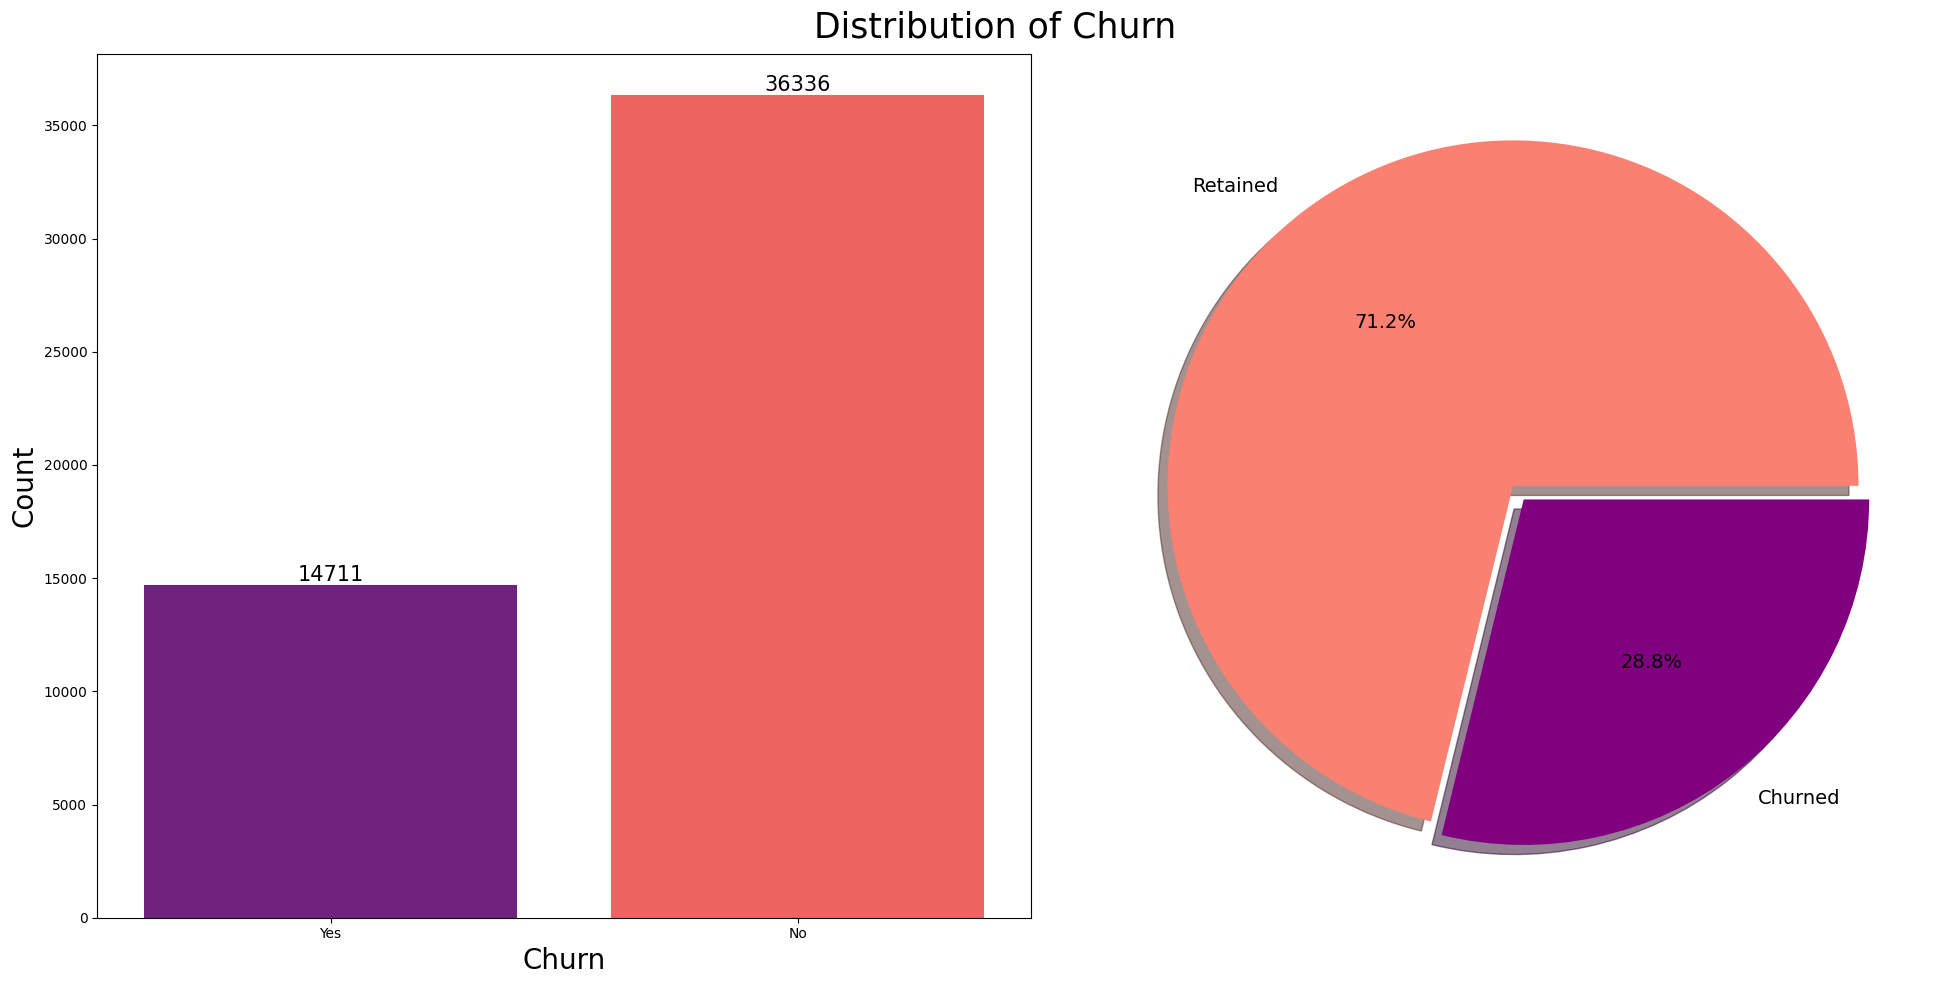

In [21]:
# Countplot and a Pie chart showing the distriution of Churn
churn_counts = train_data['Churn'].value_counts()

f, ax = plt.subplots(1, 2, figsize=(20,10))
sns.countplot(train_data, x='Churn', ax=ax[0], palette='magma', saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=15)
    ax[0].set_ylabel('Count', size=20)
    ax[0].set_xlabel('Churn', size=20)
    
    
plt.pie(x=churn_counts, labels=['Retained', 'Churned'], explode=[0, 0.05], shadow=True,
        colors=['salmon', 'purple'], autopct= '%1.1f%%', textprops={'fontsize': 14})
plt.suptitle('Distribution of Churn', size=25)
plt.tight_layout()
plt.savefig('churn_distribution.png')
plt.show()

From the countplot we can clearly see that there are the telecom company retained a total 36336 customers, which translates to 71.2% of the overall customers. A total of 14711 customers decided to leave the business, constituting to 28.8% of the overall customer. The pie chart also shows that there is a clear indication of a class imbalance with the tartget variable 'Churn', as the Retained customers appear more frequently than Churned customers.

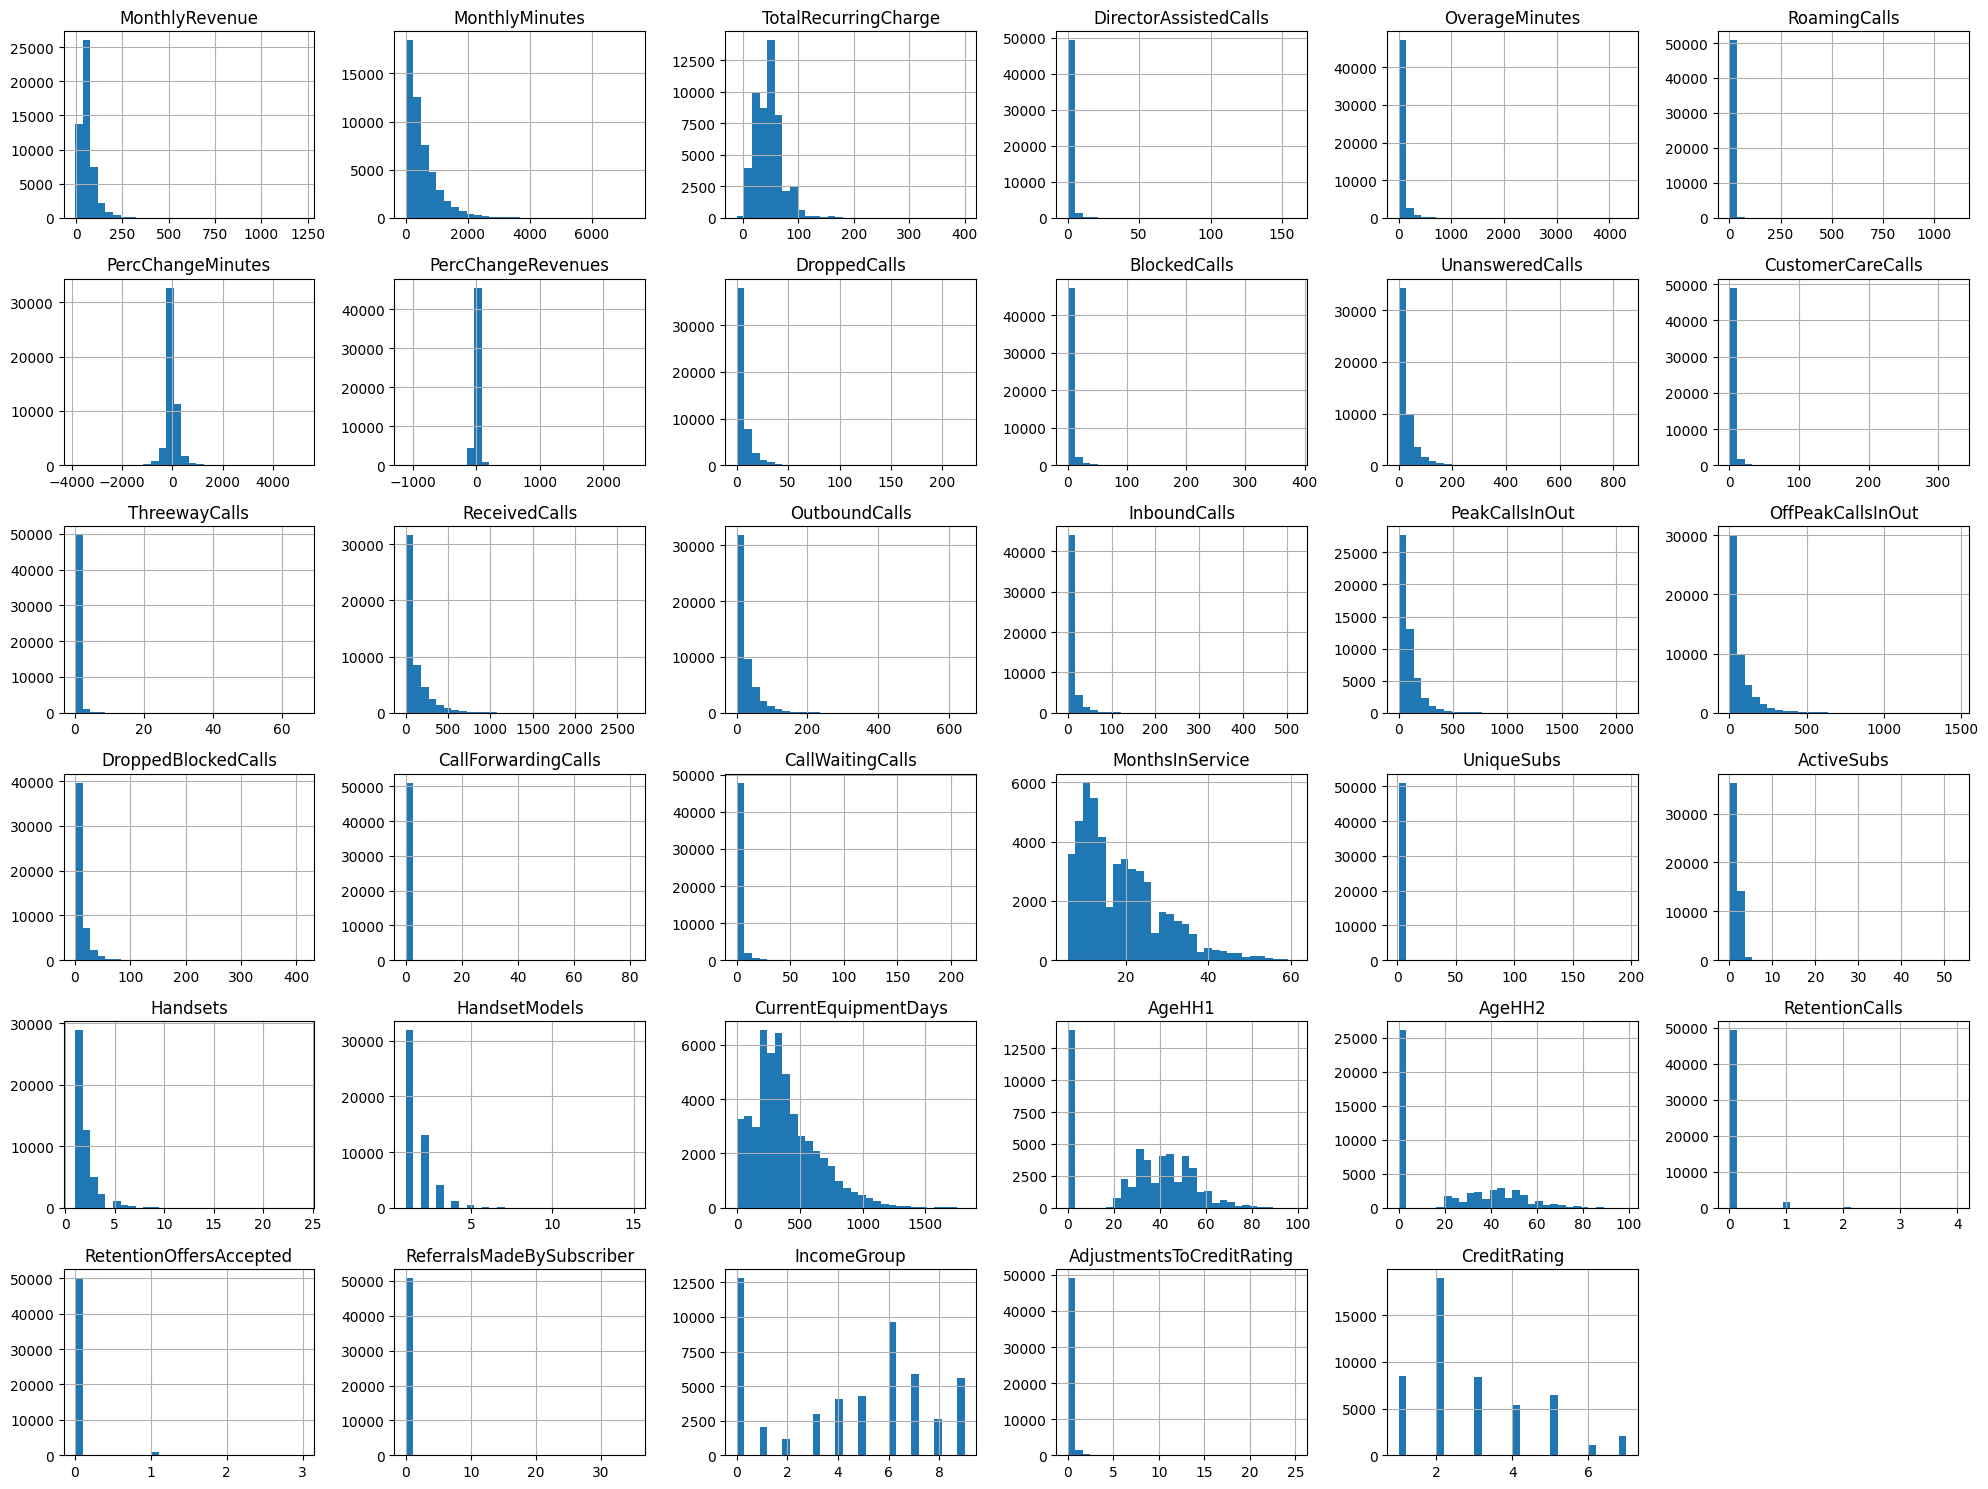

In [190]:
# dropping unnamed column from numerical features
train_data[numerical_features].hist(bins=30, figsize=(20,15))
plt.tight_layout()
plt.show()

From the histogram we can see that most of the numerical features are positively skewed and some of which are quite severely positively skewed.

# Multivariate analysis on numerical and categorical features using bar plots and count plots

In [191]:
# Simple numerical encoding of the Churn column
train_data['Churn'] = train_data['Churn'].replace({'Yes': 1, 'No': 0})

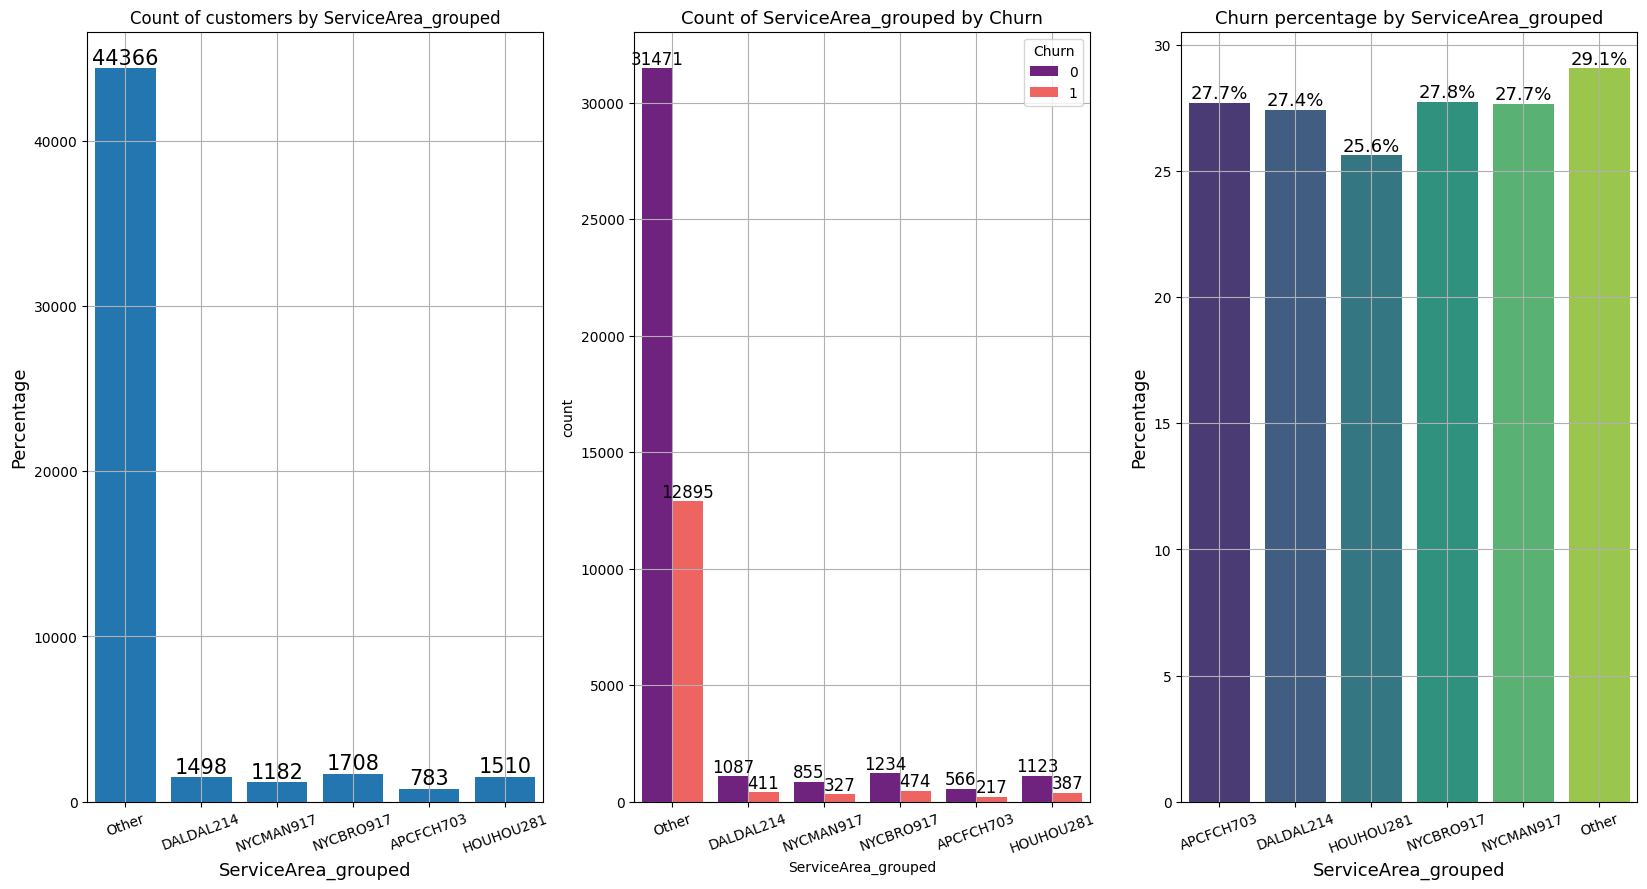

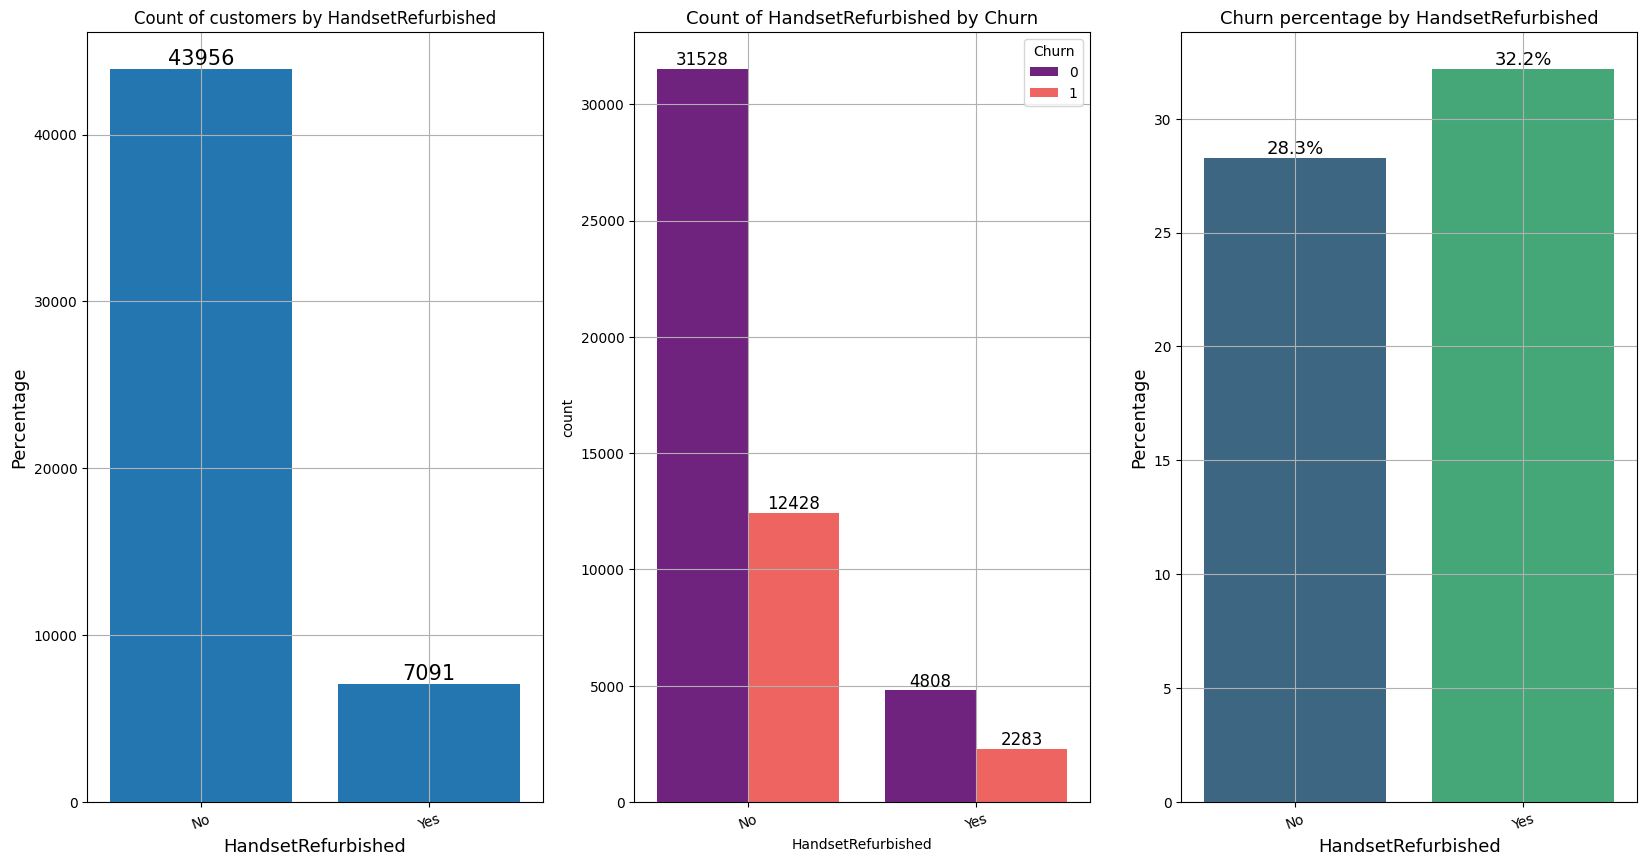

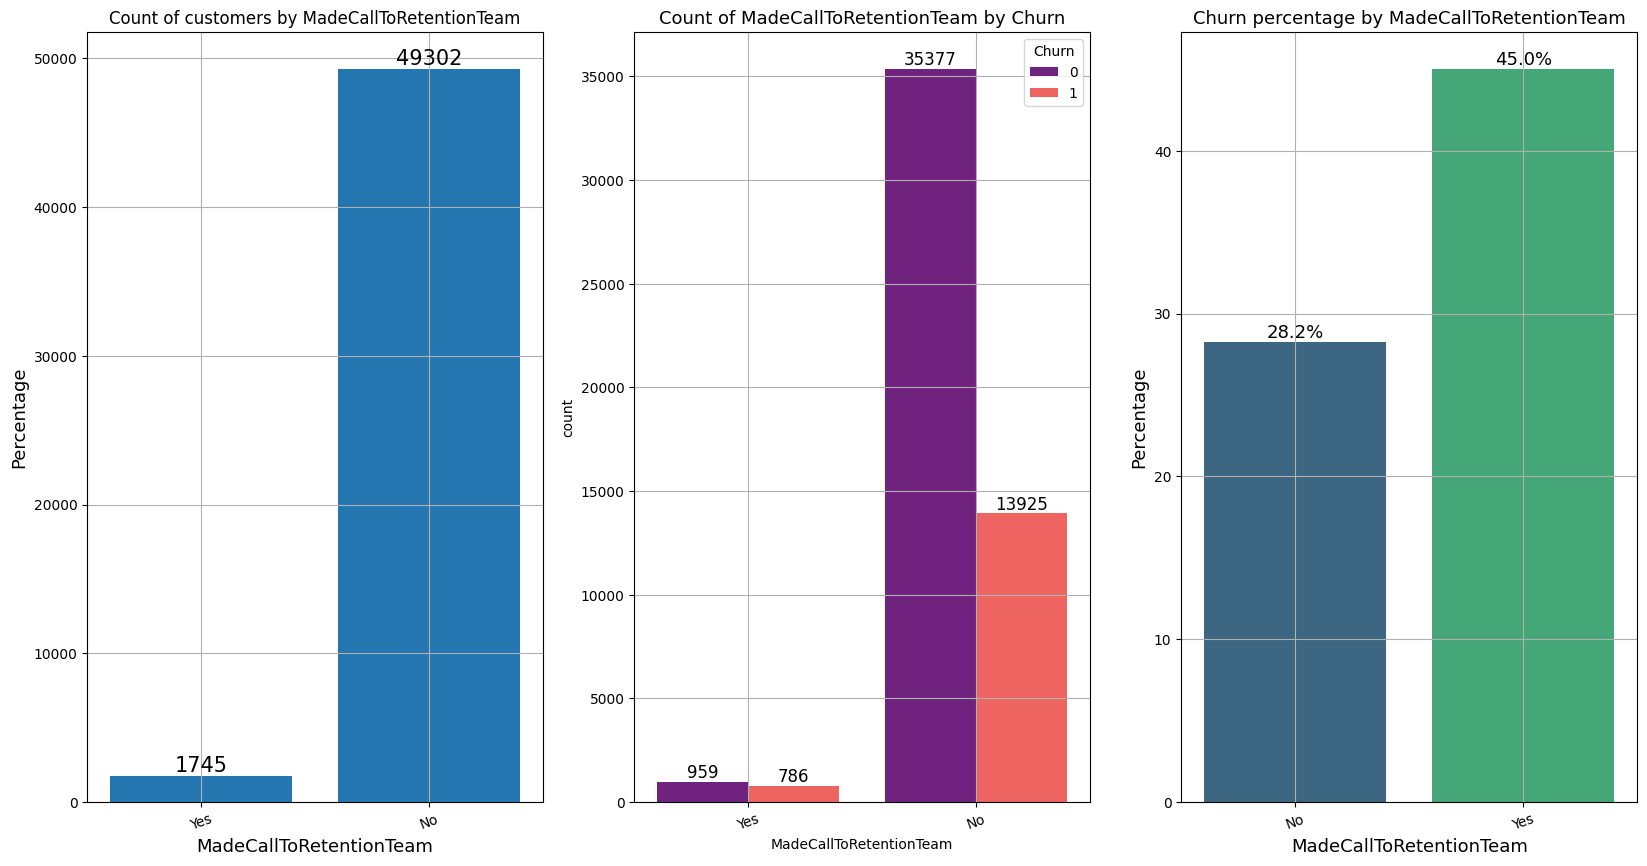

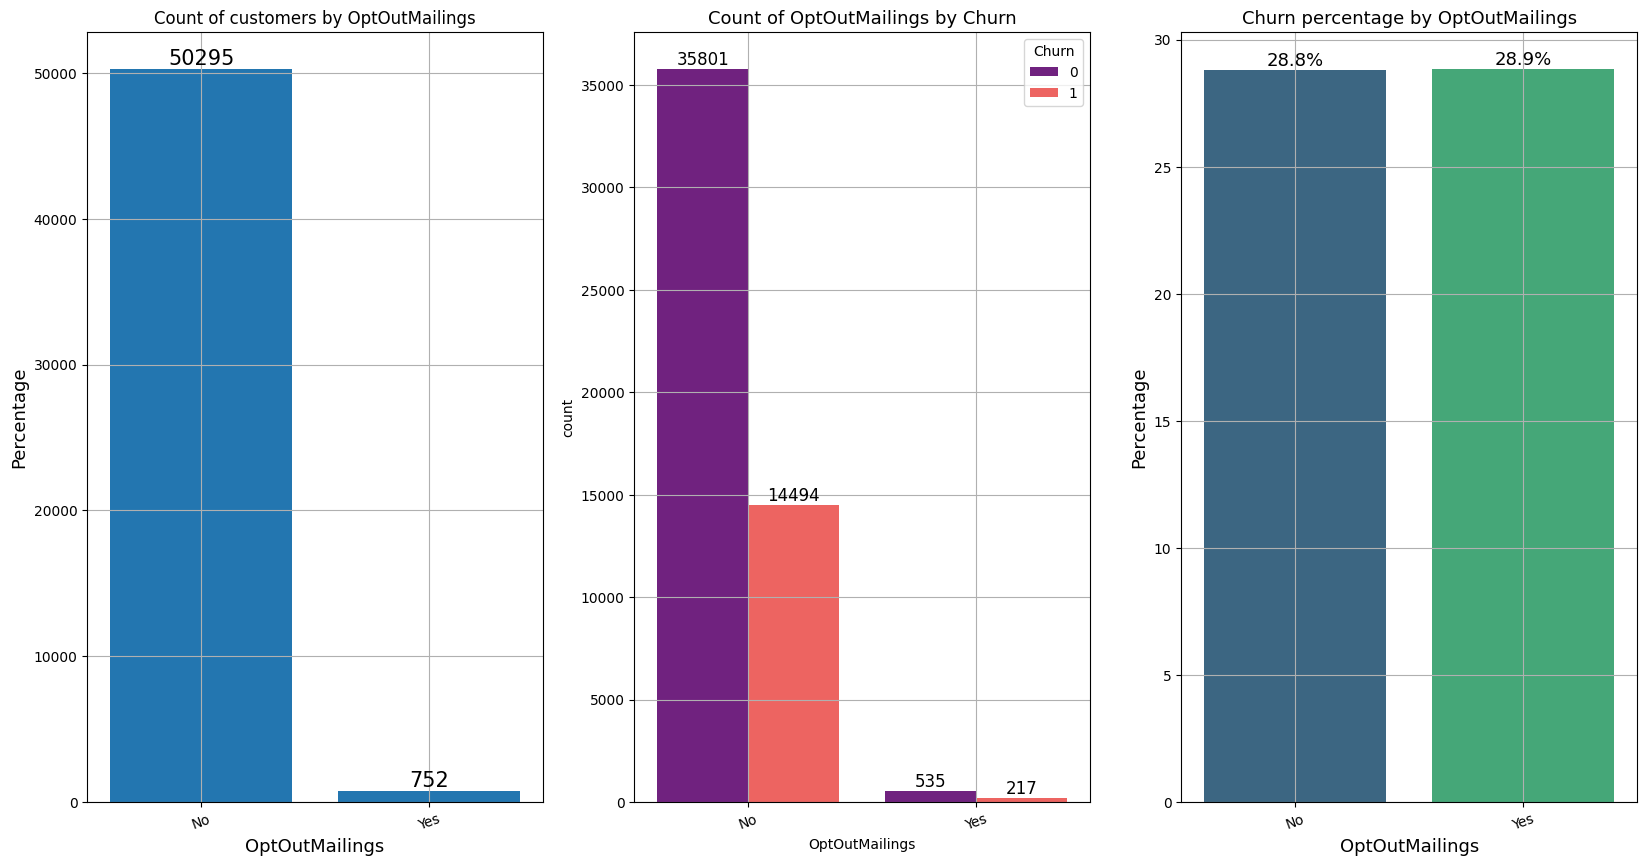

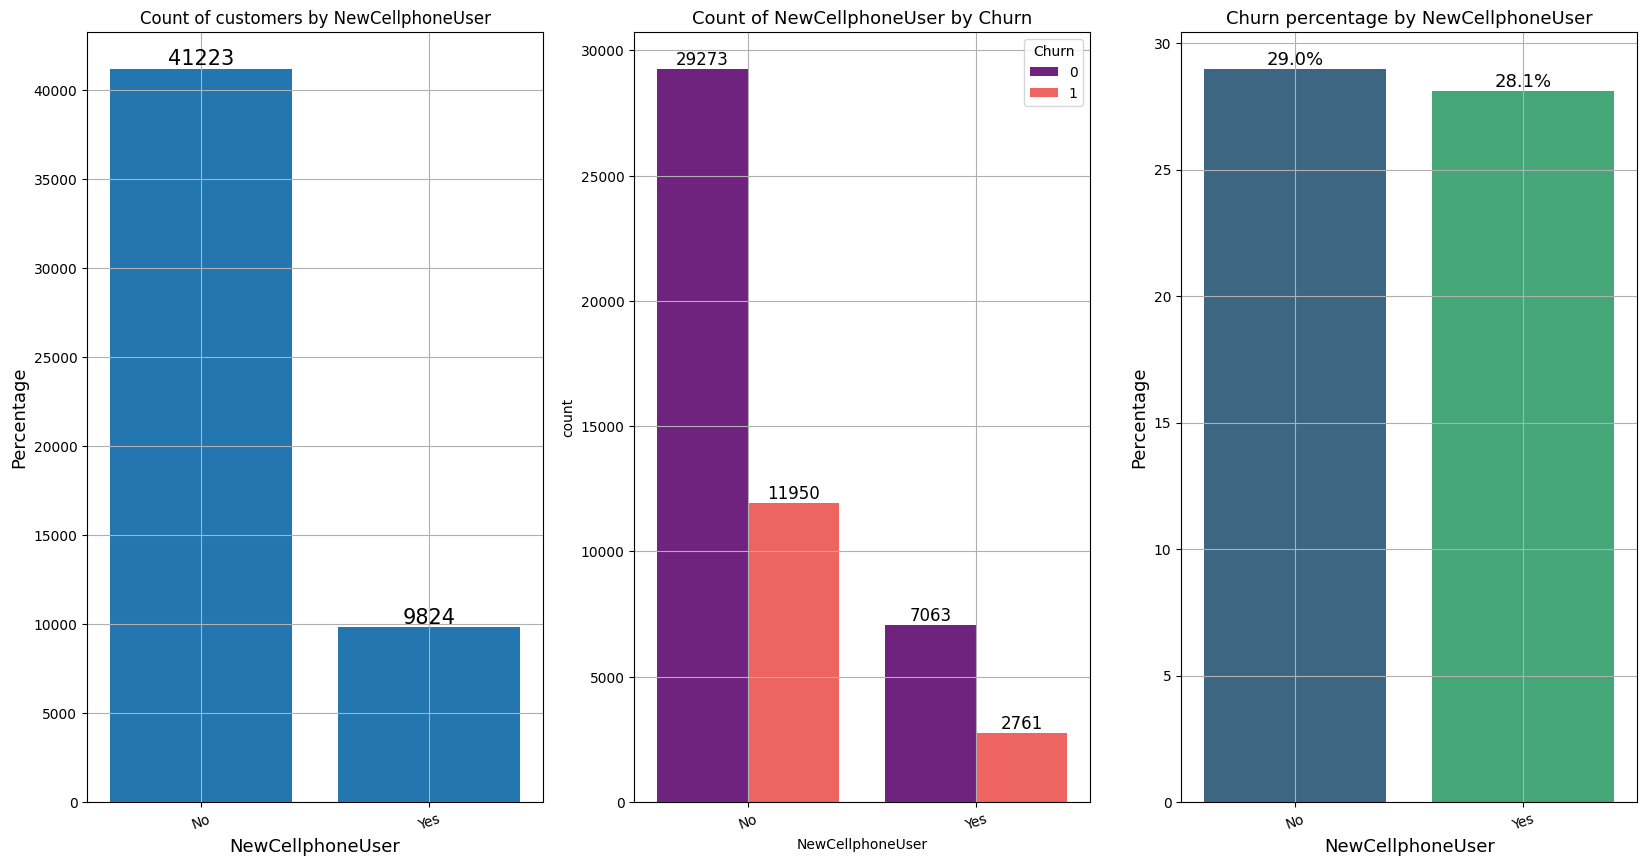

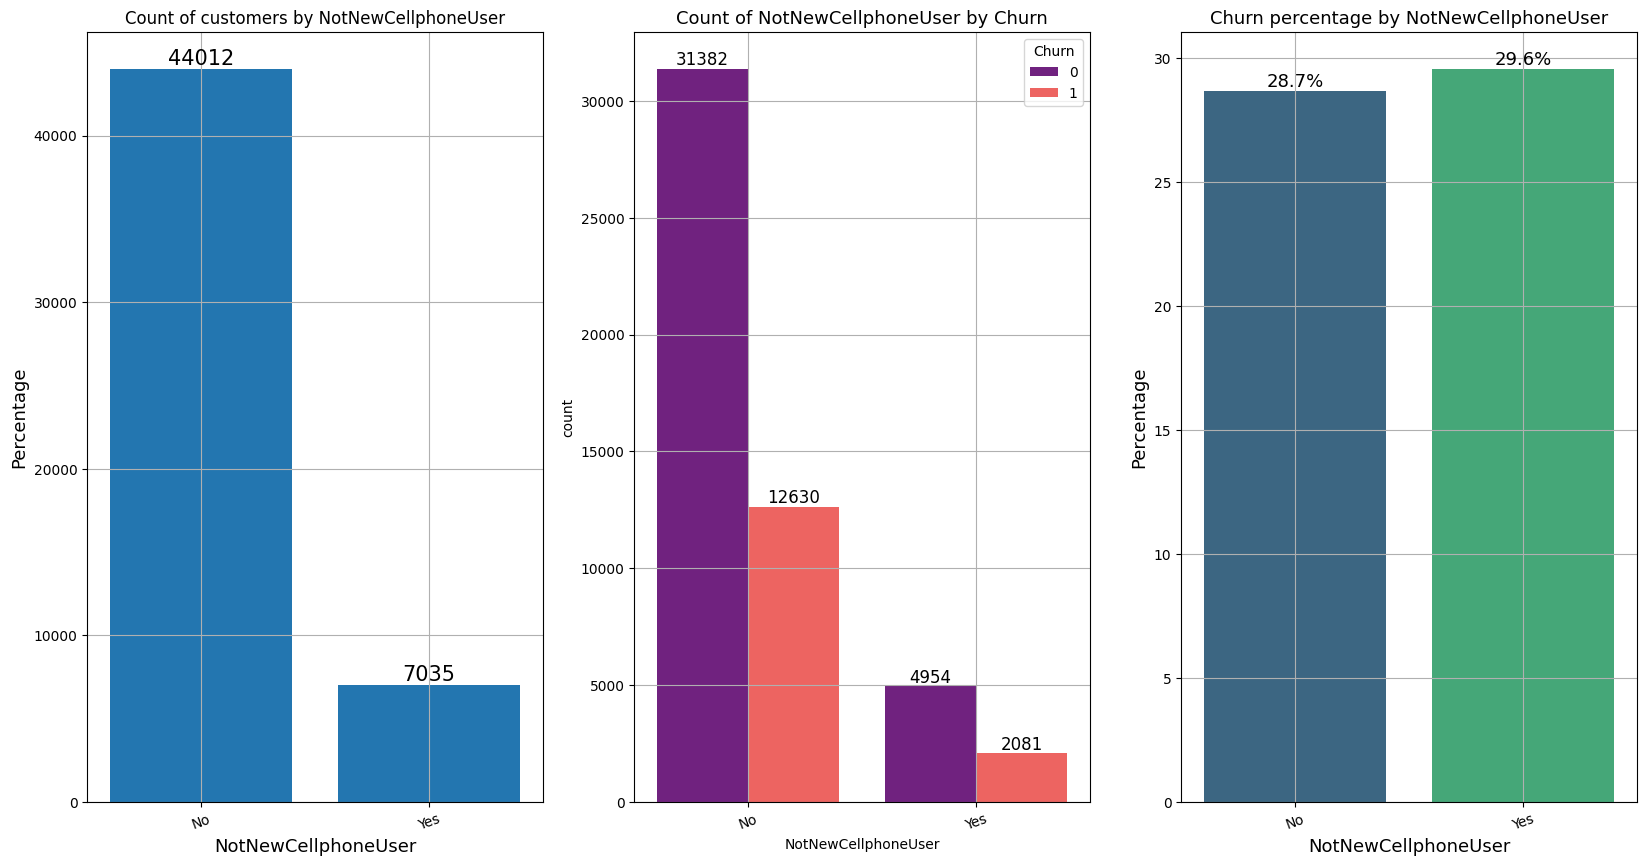

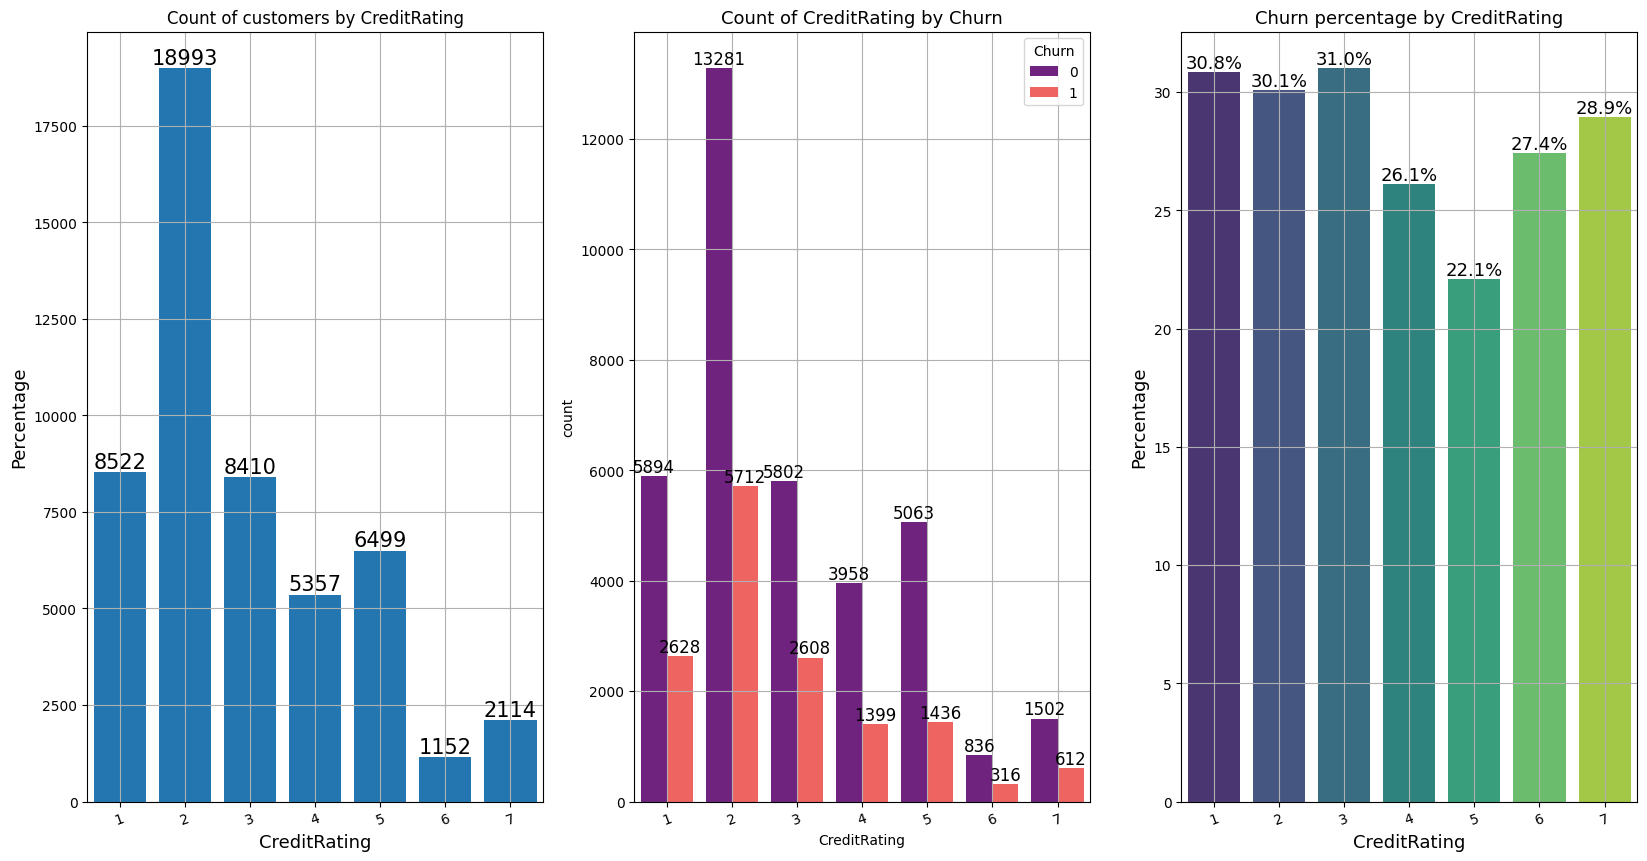

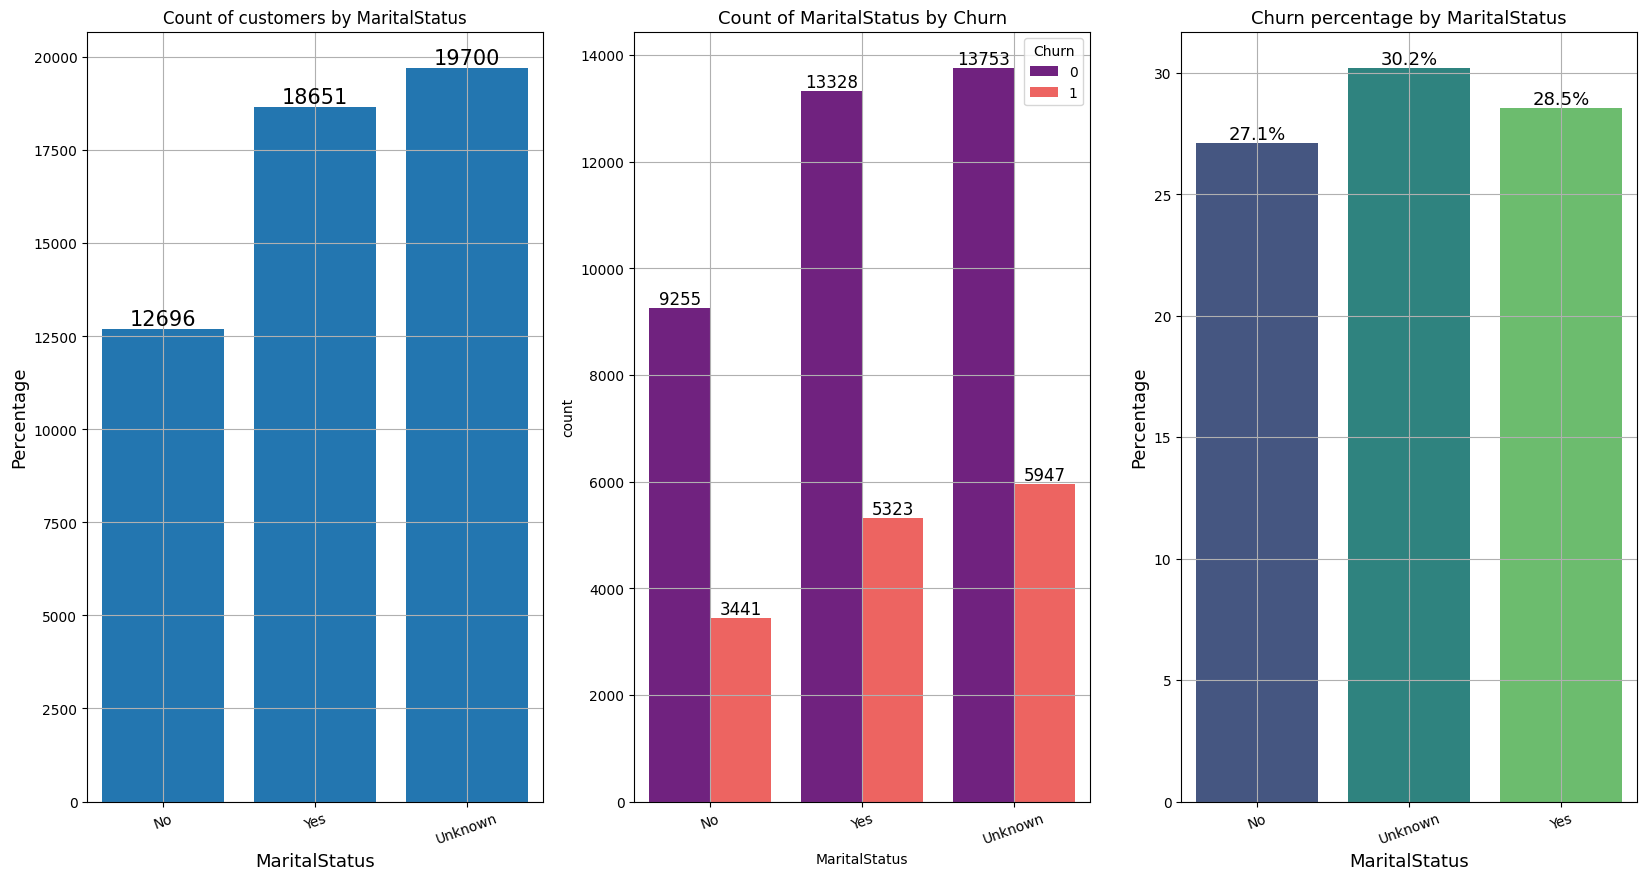

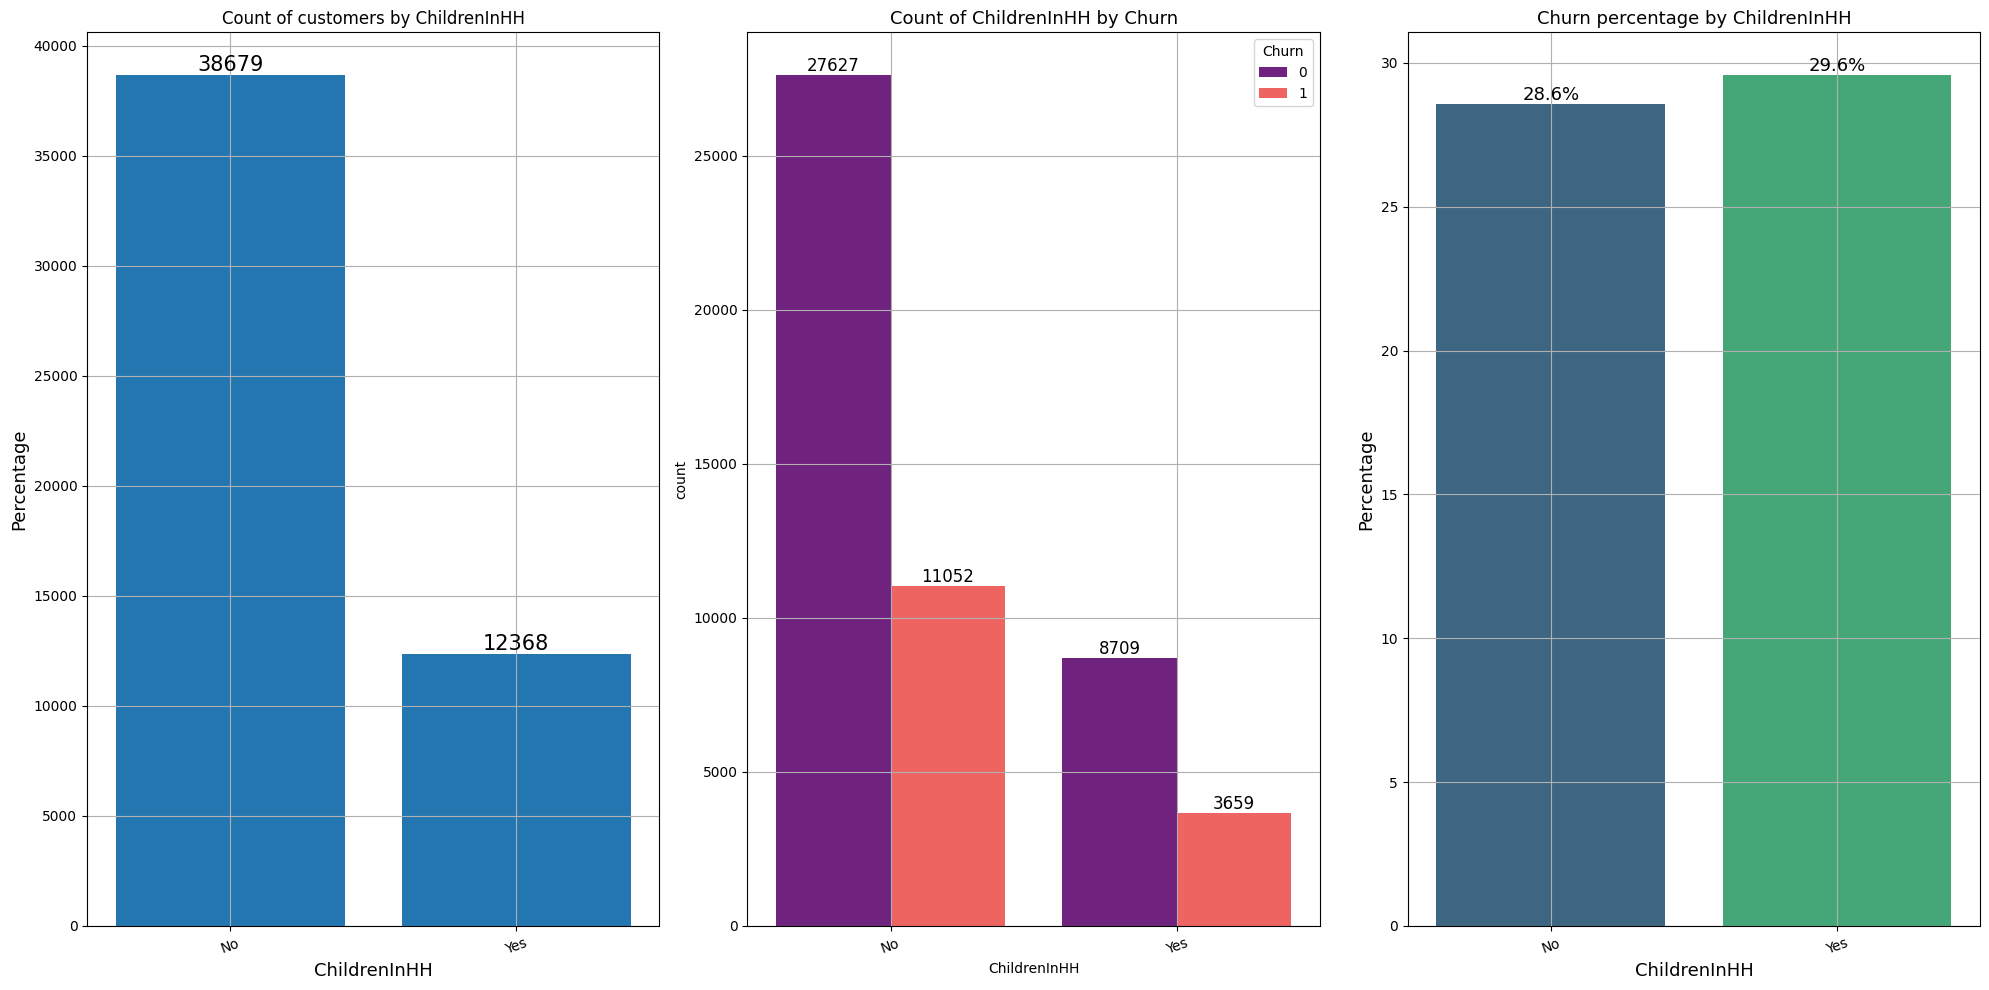

In [192]:
#Creating count plots and bar plots by looping through each feature 'categorical features'

# Comparison for the Area of service column
top_5_areas = train_data['ServiceArea'].value_counts().nlargest(5).index
train_data['ServiceArea_grouped'] = train_data['ServiceArea'].apply(lambda x: x if x in top_5_areas else 'Other')

#selected categorical feature
top_categorical_features = ['ServiceArea_grouped', 'HandsetRefurbished', 'MadeCallToRetentionTeam', 'OptOutMailings',
                            'NewCellphoneUser', 'NotNewCellphoneUser', 'CreditRating', 'MaritalStatus', 'ChildrenInHH']

for feature in top_categorical_features:
    fig, ax = plt.subplots(1, 3, figsize=(20,10))
    ax = ax.flatten()
    sns.countplot(train_data, x=feature, ax=ax[0], saturation=0.95)
    for container in ax[0].containers:
        ax[0].bar_label(container, color='black', size=15)
    ax[0].set_title(f'Count of customers by {feature}')
    ax[0].set_xlabel(f'{feature}', size=13)
    ax[0].set_ylabel('Percentage', size=13)
    ax[0].tick_params(axis='x', rotation=20)
    ax[0].grid()
    
    sns.countplot(train_data, x=feature, hue='Churn', palette='magma', ax=ax[1], saturation=0.95)
    for container in ax[1].containers:
        ax[1].bar_label(container, color='black', size=12)
    ax[1].set_title(f'Count of {feature} by Churn', size=13)
    ax[1].grid()
    ax[1].tick_params(axis='x', rotation=20)
    
    churn_rates = (train_data.groupby(feature)['Churn'].mean() * 100) 
    colors = sns.color_palette("viridis", len(churn_rates))
    sns.barplot(x=churn_rates.index , y=churn_rates.values, ax=ax[2], palette=colors)
    for container in ax[2].containers:
        ax[2].bar_label(container, fmt='%.1f%%', color='black', size=13)
    ax[2].set_title(f'Churn percentage by {feature}', size=13)
    ax[2].set_xlabel(f'{feature}', size=13)
    ax[2].set_ylabel('Percentage', size=13)
    ax[2].grid()
    ax[2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

- Most of the customers have a Credit rating between 1-3, and customers with a credit rating in that range are most likely churn as compared to those with a credit rating of 5+
- Only 1,745 customers called retention vs 49,302 who didn't and 45% oof those who did churned, compared to the 28.2% of those who called but did not churned, which goes to show that customers who make calls to the retention team are most likely to churn.

In [193]:
# creating a data copy
train_data1 = train_data.copy()

# Checking for Outliers

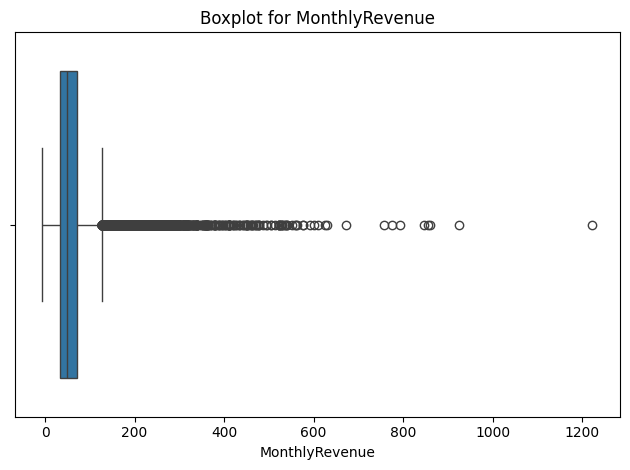

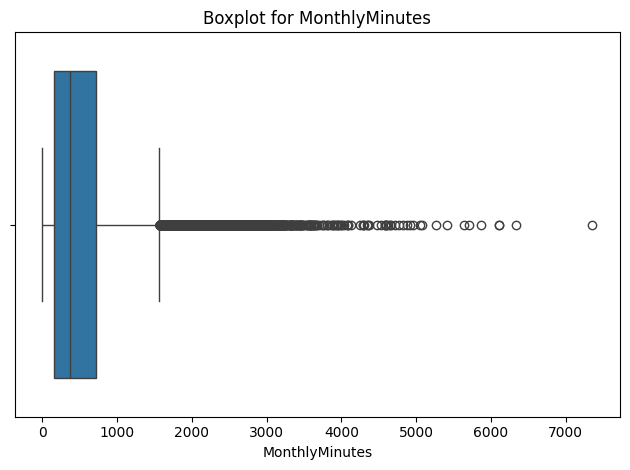

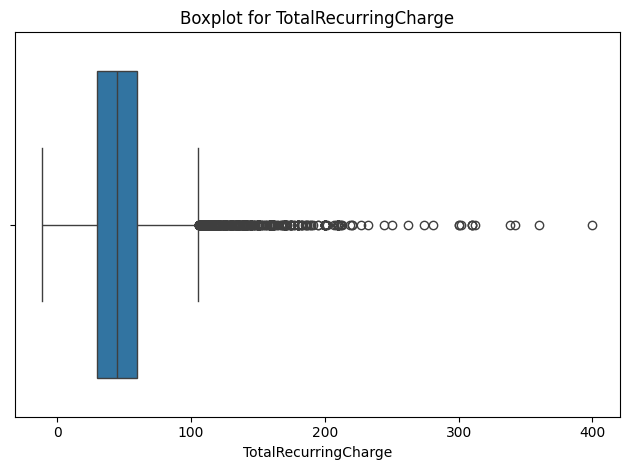

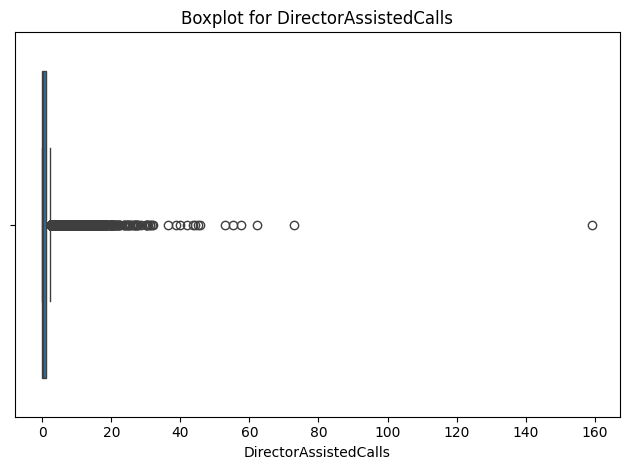

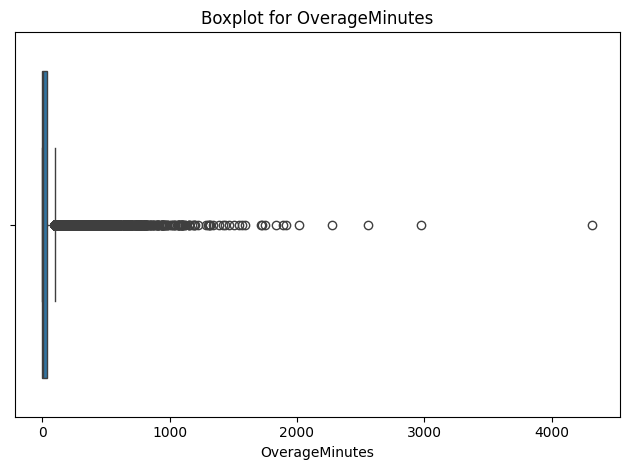

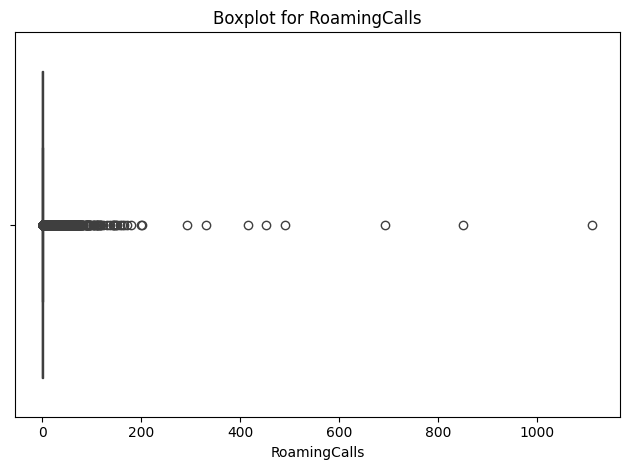

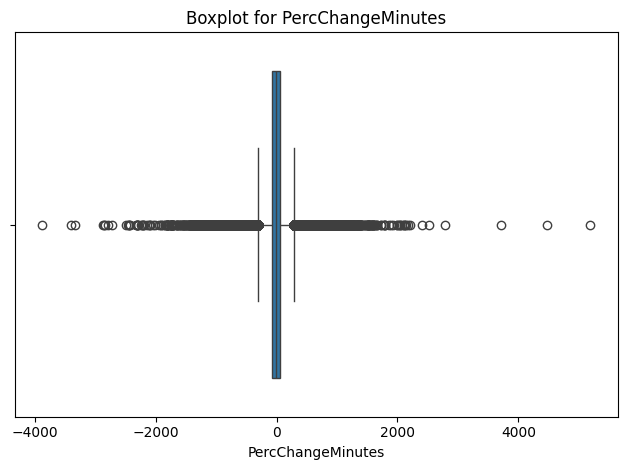

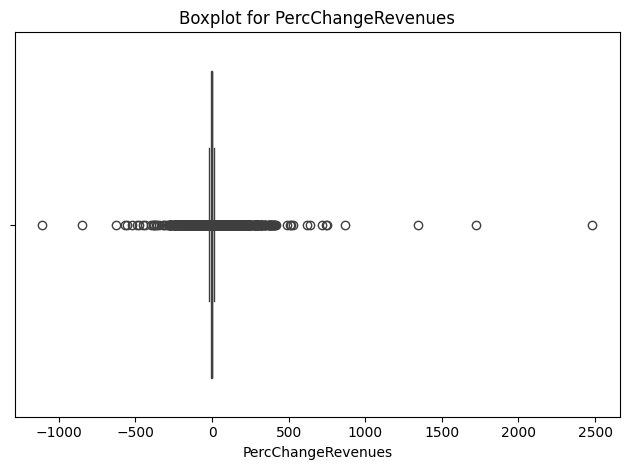

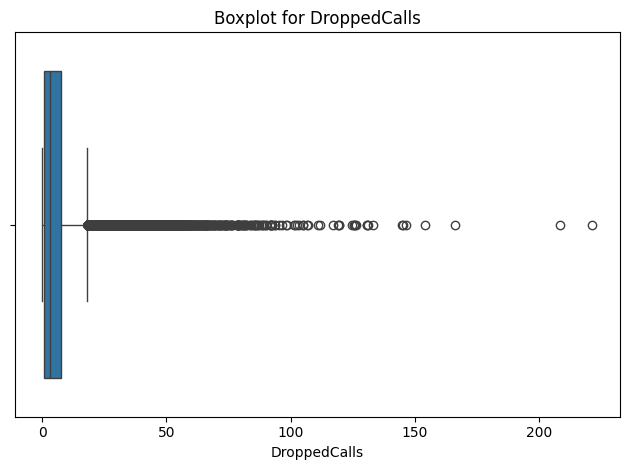

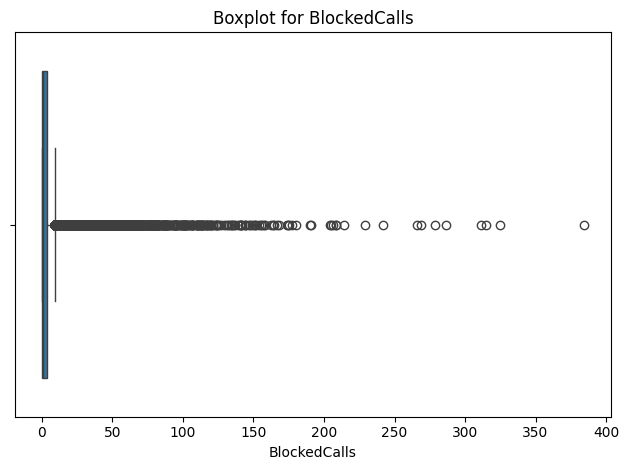

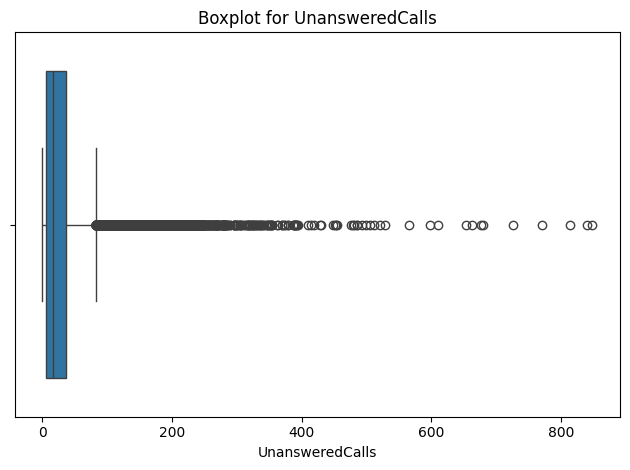

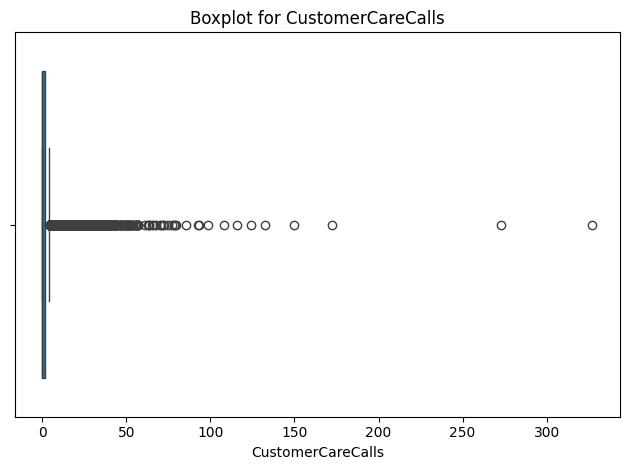

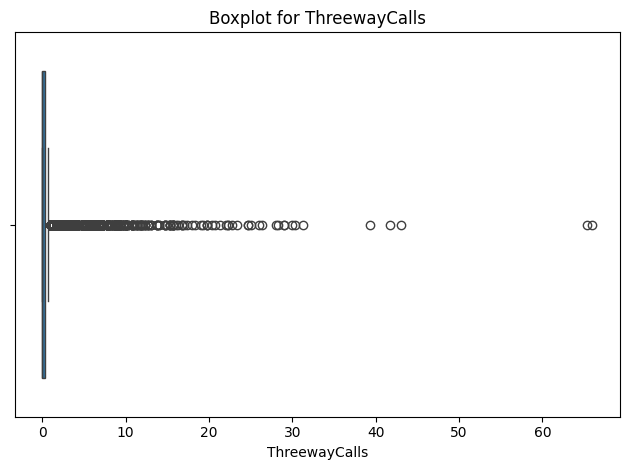

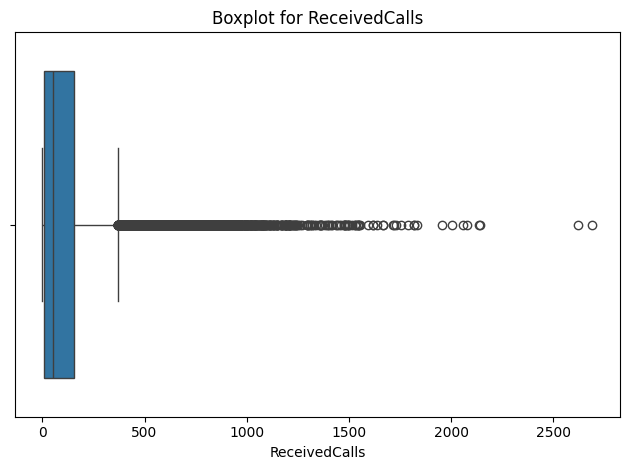

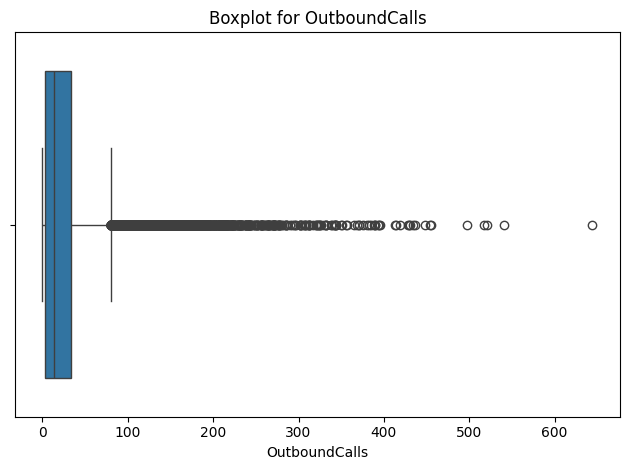

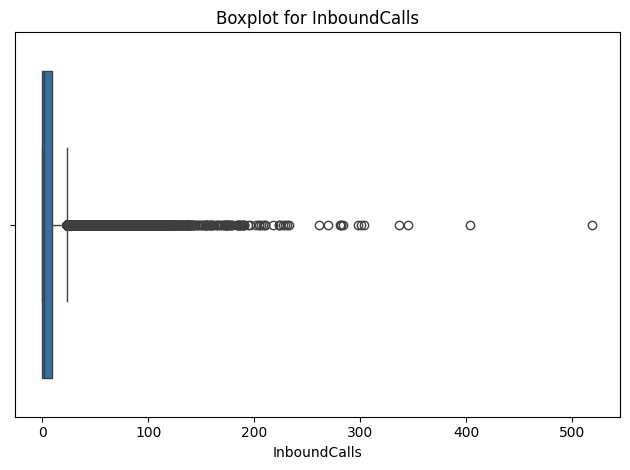

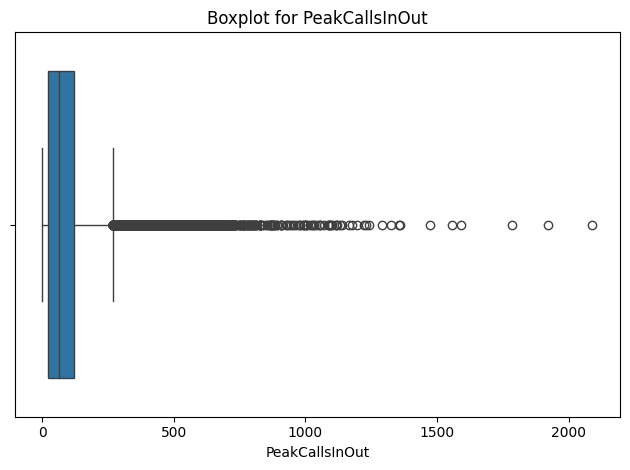

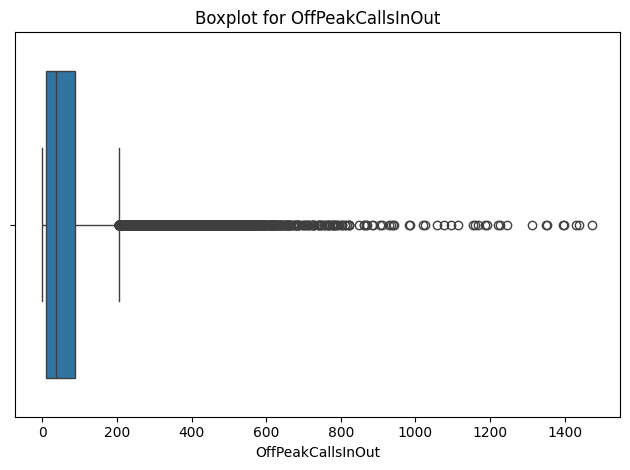

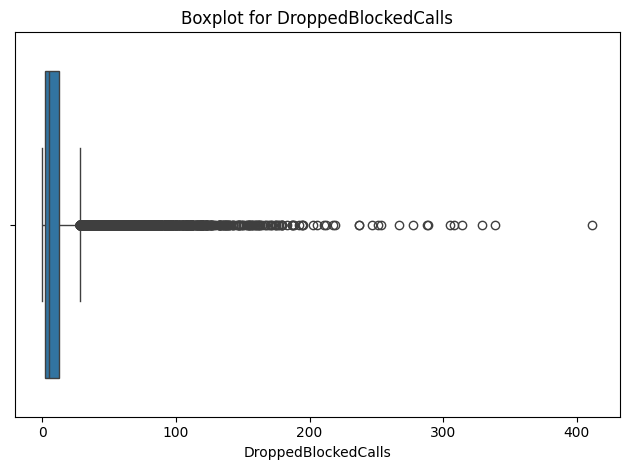

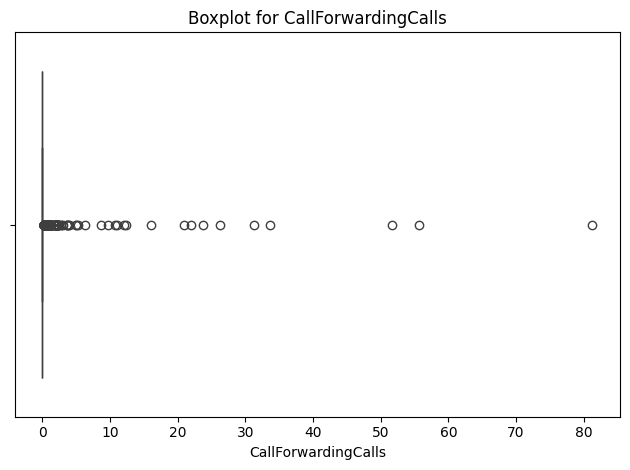

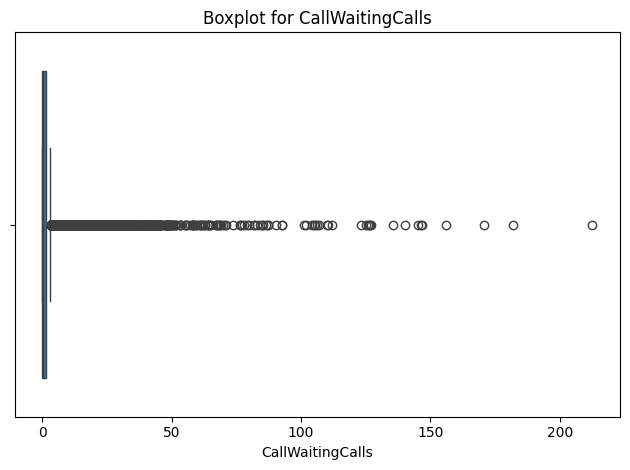

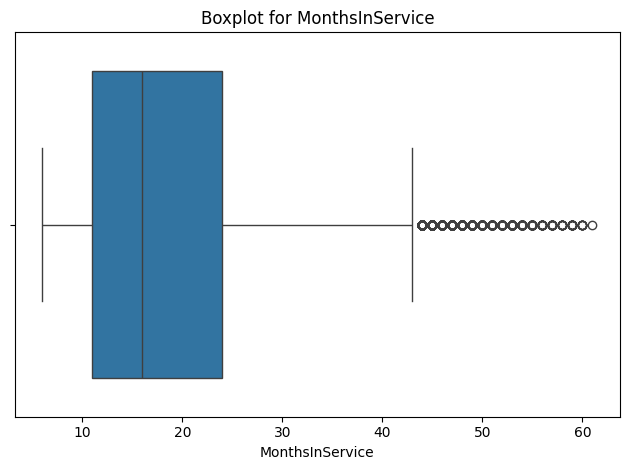

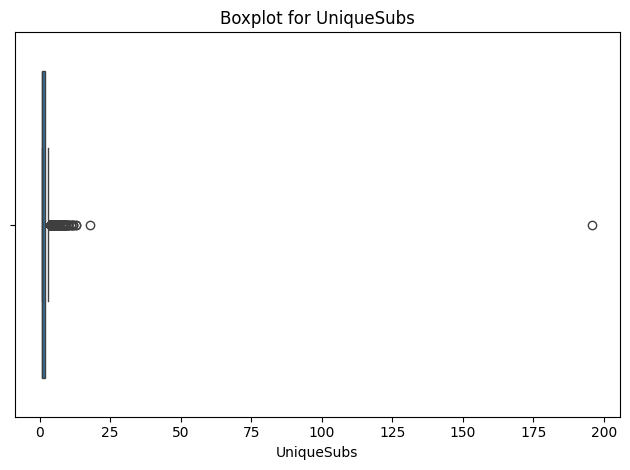

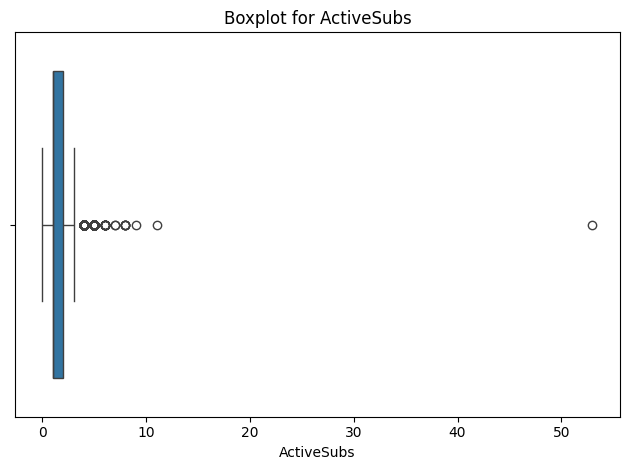

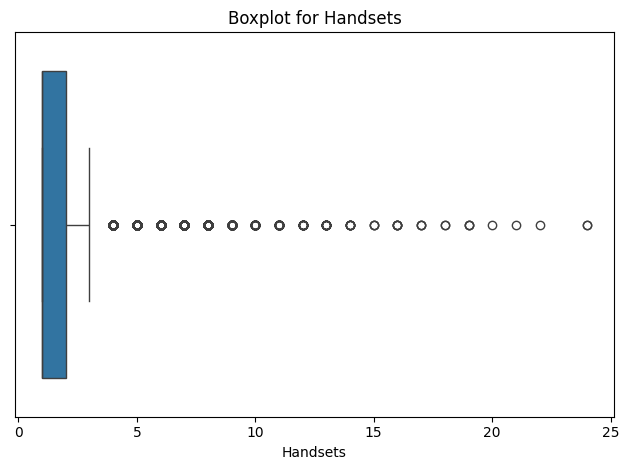

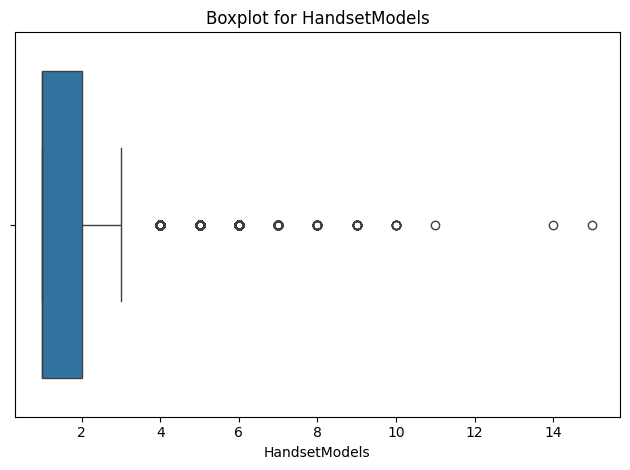

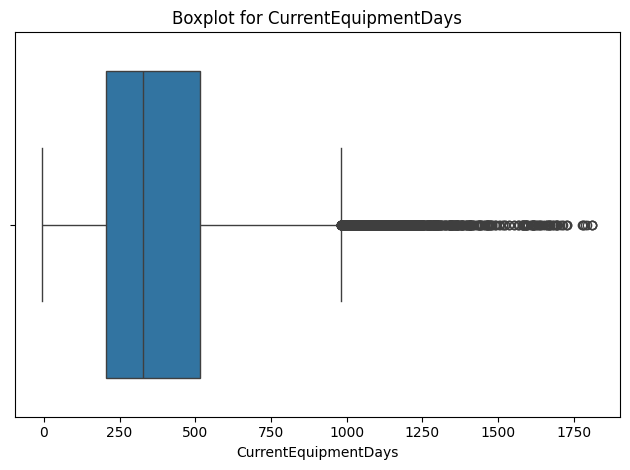

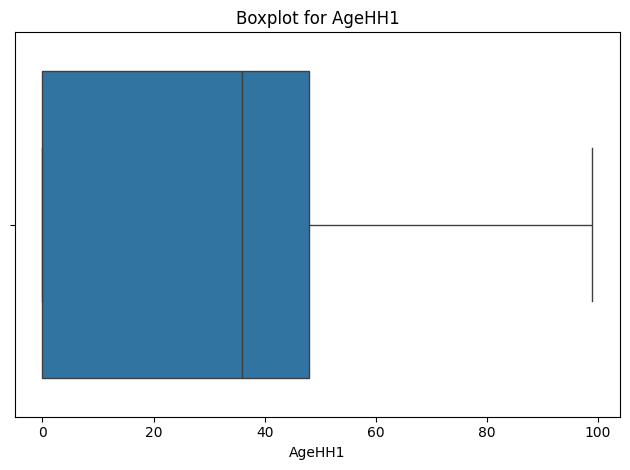

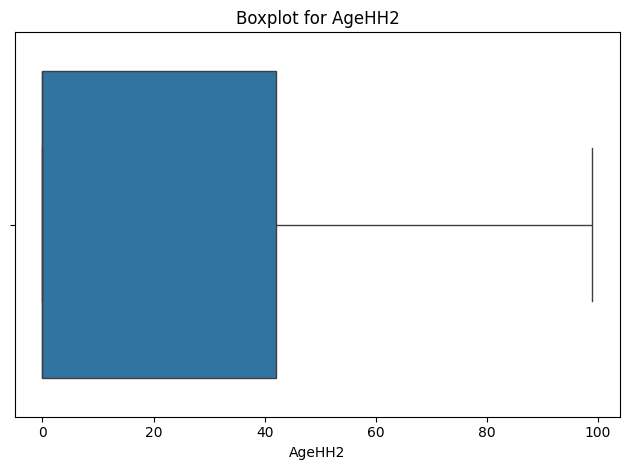

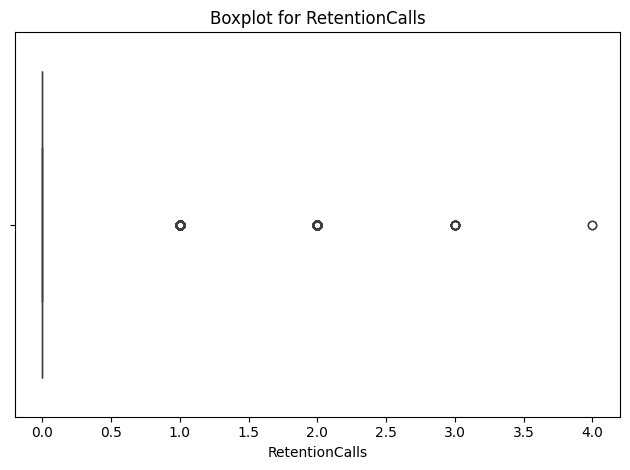

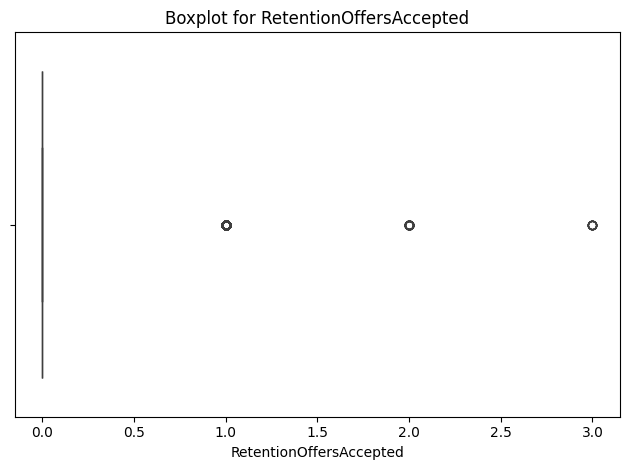

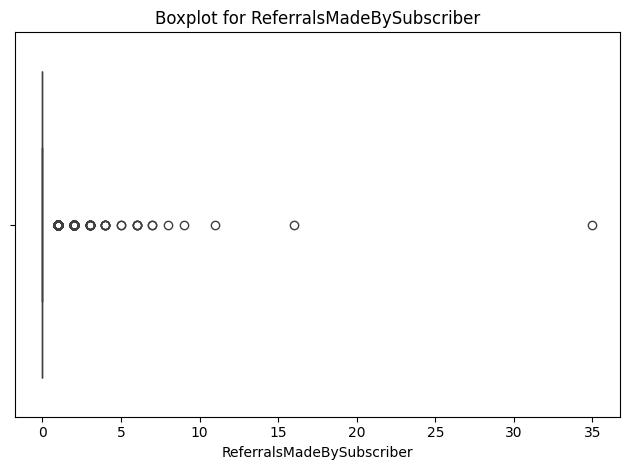

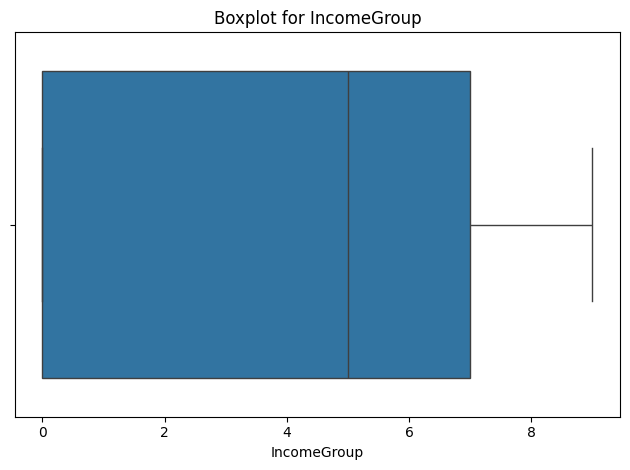

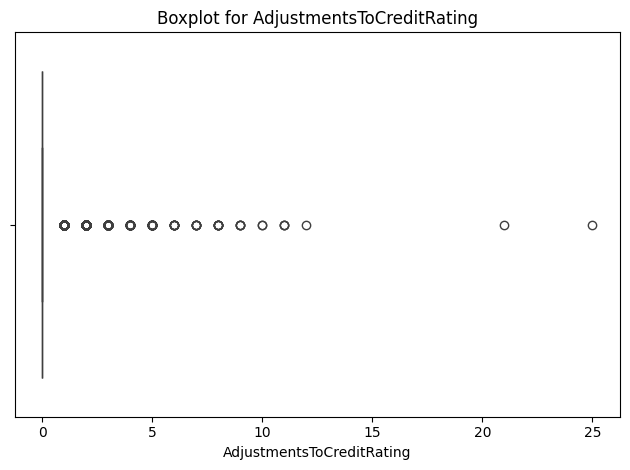

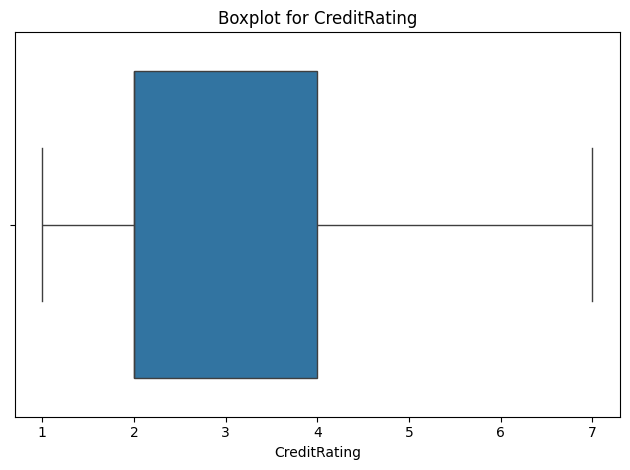

In [194]:
# Creating boxplots to determine if there are any outliers
for feature in numerical_features:
    sns.boxplot(train_data1, x=feature)
    plt.title(f'Boxplot for {feature}')
    plt.tight_layout()
    plt.show()

In [195]:
# Outlier count for numerical columns

for col in numerical_features:
    Q1 = train_data1[col].quantile(0.25)
    Q3 = train_data1[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Identify outliers
    outliers = train_data1[(train_data1[col] < Q1 - 1.5*IQR) | (train_data1[col] > Q3 + 1.5*IQR)]
    print(f'{col}: {len(outliers)} outliers')

MonthlyRevenue: 3009 outliers
MonthlyMinutes: 2588 outliers
TotalRecurringCharge: 824 outliers
DirectorAssistedCalls: 5530 outliers
OverageMinutes: 5980 outliers
RoamingCalls: 8991 outliers
PercChangeMinutes: 6926 outliers
PercChangeRevenues: 13471 outliers
DroppedCalls: 3712 outliers
BlockedCalls: 5517 outliers
UnansweredCalls: 3630 outliers
CustomerCareCalls: 6721 outliers
ThreewayCalls: 4622 outliers
ReceivedCalls: 3641 outliers
OutboundCalls: 3342 outliers
InboundCalls: 4973 outliers
PeakCallsInOut: 2803 outliers
OffPeakCallsInOut: 3624 outliers
DroppedBlockedCalls: 3936 outliers
CallForwardingCalls: 234 outliers
CallWaitingCalls: 7448 outliers
MonthsInService: 1218 outliers
UniqueSubs: 1874 outliers
ActiveSubs: 611 outliers
Handsets: 4414 outliers
HandsetModels: 2008 outliers
CurrentEquipmentDays: 1446 outliers
AgeHH1: 0 outliers
AgeHH2: 0 outliers
RetentionCalls: 1745 outliers
RetentionOffersAccepted: 881 outliers
ReferralsMadeBySubscriber: 2384 outliers
IncomeGroup: 0 outliers
A

Our data has many outliers, some very extreme but they will be handled later.

# Multivariate analysis using a pairplot and a heatmap 

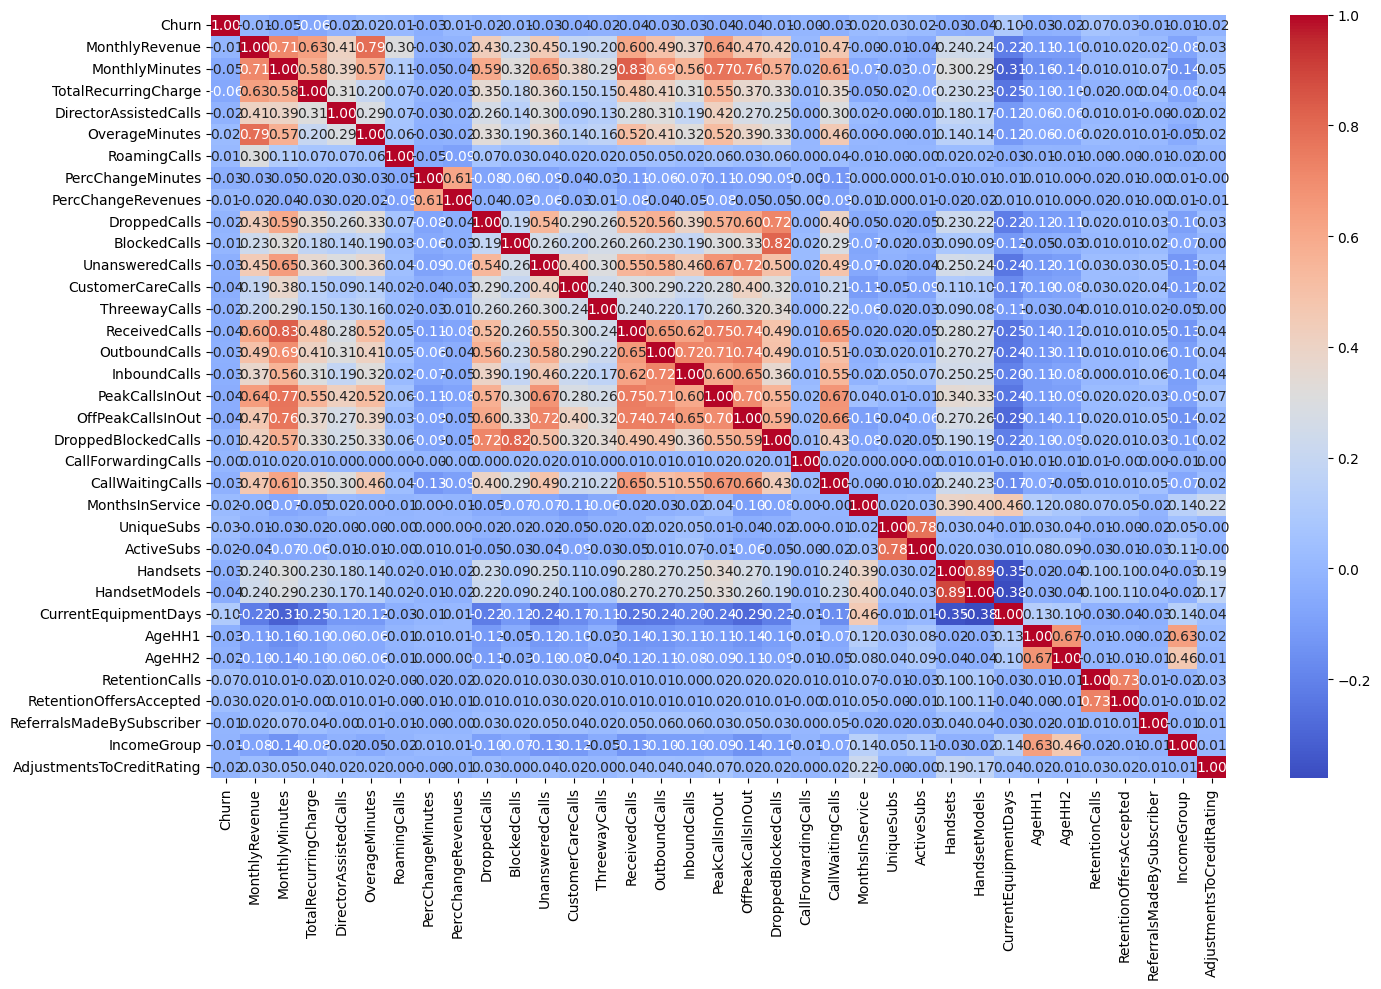

In [196]:
# Constructing a heatmap to show correlation between numerical independent features with Churn

features = ['Churn', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls',
                                'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls',
                                'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls',
                                'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls',
                                'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs',
                                'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2',
                                'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating']

plt.figure(figsize=(15,10))
sns.heatmap(train_data1[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

The heatmap indicates that there some features that are highly correlated with each other. High correlation is categorized by a correlation that is greater than 0.75. Our independent variables are have a low correlation with our target variable 'Churn'.

# FEATURE ENGINEERING

# Removing low variance features
In this section i'll be removing features with a variance of 0 because a variance of 0 means there isn't much variation within that particular feature and that won't really improve our model performance, so they are basically redundant.

In [197]:
train_data1[numerical_features].var().round(2).sort_values(ascending=False)

MonthlyMinutes               279905.31
PercChangeMinutes             65837.09
CurrentEquipmentDays          64414.18
ReceivedCalls                 27717.55
PeakCallsInOut                11013.97
OverageMinutes                 9300.75
OffPeakCallsInOut              8603.06
MonthlyRevenue                 1974.85
PercChangeRevenues             1554.91
UnansweredCalls                1511.36
OutboundCalls                  1239.68
TotalRecurringCharge            567.03
AgeHH2                          562.51
AgeHH1                          479.48
InboundCalls                    277.75
DroppedBlockedCalls             241.97
BlockedCalls                    119.83
RoamingCalls                     96.10
MonthsInService                  96.04
DroppedCalls                     81.79
CallWaitingCalls                 31.19
CustomerCareCalls                25.97
IncomeGroup                       9.85
DirectorAssistedCalls             4.95
CreditRating                      2.51
Handsets                 

Though we have features with variances as low as 0.02, we will not be removing them, as they are still significant

# feature creation

In [198]:
# How frequent do Customer Care make calls to the customer per month
train_data1['CustomerSupportMonth'] = train_data['CustomerCareCalls'] / train_data['MonthsInService']

# Offer acceptance rate per retention call made
train_data1['OfferAcceptanceRate'] = train_data['RetentionOffersAccepted'] / (train_data['RetentionCalls'] + 1)

# Financial stress Score
low_income = train_data['IncomeGroup'] <= 2
credit_risk = train_data['CreditRating'] <= 2
credit_adjustment_flag = train_data['AdjustmentsToCreditRating'] > 0
revenue_drop = train_data['PercChangeRevenues'] < -0.1
train_data1['FinancialDistressScore'] = low_income + credit_risk + credit_adjustment_flag + revenue_drop 

In [199]:
# Doing the same for test_data

# How frequent do Customer Care make calls to the customer per month
test_data['CustomerSupportMonth'] = test_data['CustomerCareCalls'] / test_data['MonthsInService']

# Offer acceptance rate per retention call made
test_data['OfferAcceptanceRate'] = test_data['RetentionOffersAccepted'] / (test_data['RetentionCalls'] + 1)

# Financial stress Score
low_income = test_data['IncomeGroup'] <= 2
credit_risk = test_data['CreditRating'] <= 2
credit_adjustment_flag = test_data['AdjustmentsToCreditRating'] > 0
revenue_drop = test_data['PercChangeRevenues'] < -0.1
test_data['FinancialDistressScore'] = low_income + credit_risk + credit_adjustment_flag + revenue_drop 


In [200]:
train_data1.columns

Index(['Churn', 'MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge',
       'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls',
       'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls',
       'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls',
       'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut',
       'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls',
       'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs',
       'ServiceArea', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays',
       'AgeHH1', 'AgeHH2', 'ChildrenInHH', 'HandsetRefurbished',
       'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership',
       'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings',
       'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls',
       'RetentionOffersAccepted', 'NewCellphoneUser', 'NotNewCellphoneUser',
       'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMoto

In [201]:
# Redefining categorical and numerical features

categorical_features = [col for col in train_data1.columns if train_data1[col].dtype == 'str']
numerical_features = [col for col in train_data1.columns if train_data1[col].dtype in ['int64', 'float64']]

print(f'Total number of Categorical features: {len(categorical_features)}')
print(f'Total number of Numerical features: {len(numerical_features)}')

Total number of Categorical features: 21
Total number of Numerical features: 37


In [202]:
print(f'Categorical features: {categorical_features}\n')
print(f'Numerical features: {numerical_features}')

Categorical features: ['ServiceArea', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'PrizmCode', 'Occupation', 'MaritalStatus', 'ServiceArea_grouped']

Numerical features: ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'Re

In [203]:
# Removing 'ServiceArea' because it has too many unique values
categorical_features.remove('ServiceArea')
categorical_features.remove('ServiceArea_grouped')

# MODEL DEVELOPMENT

In [204]:
#Import libraries for the machine learning pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn import svm
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
import catboost as cb
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

In [205]:
# Splitting the dataset
X = train_data1.drop(columns=['Churn', 'ServiceArea', 'ServiceArea_grouped'])
y = train_data1['Churn']

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

y_train = y_train.astype(int)
y_val = y_val.astype(int)

In [206]:
print(f'{categorical_features}\n')

print(numerical_features)

['ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'PrizmCode', 'Occupation', 'MaritalStatus']

['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'RetentionCalls', 'RetentionOffersAccepted', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'AdjustmentsToCreditRating', 'CreditRat

# Outlier handling with winsorization

In [207]:
# The winsorization technique will be applied to both X_train and X_test separately to avoid data leakage
for col in numerical_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    X_val[col] = X_val[col].clip(lower_bound, upper_bound)

# Models, parameters and preprocessor 

In [208]:
# Defining models
models = {
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': cb.CatBoostClassifier(random_state=42, verbose=0)
}

# defining parameters
xgb_grid = {
    'classifier__n_estimators': [200,400,600],
    'classifier__learning_rate': [0.01,0.05,0.1],
    'classifier__max_depth': [3,5,7],
    'classifier__min_child_weight': [1,3,5],
    'classifier__subsample': [0.7,0.8,1],
    'classifier__colsample_bytree': [0.7,0.8,1],
    'classifier__gamma': [0,0.1,0.3]
}

lgbm_grid = {
    'classifier__n_estimators': [200,400,600],
    'classifier__learning_rate': [0.01,0.05,0.1],
    'classifier__max_depth': [5,10,15],
    'classifier__num_leaves': [31,50,100],
    'classifier__subsample': [0.7,0.8,1],
    'classifier__colsample_bytree': [0.7,0.8,1]
}

cat_grid = {
    "classifier__depth": [4, 6, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.1],
    "classifier__iterations": [200, 500, 1000],
    "classifier__l2_leaf_reg": [1, 3, 5, 7],
    "classifier__border_count": [32, 64, 128]
}

params_grid = {
    'XGBoost': xgb_grid,
    'LightGBM': lgbm_grid,
    'CatBoost': cat_grid
}

# defining the prerocessors

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

# Using stratifies K-fold for class imbalance
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Building the pipeline with fine tuning (GridSearchCV)

In [209]:
# Looping through the models
best_models = {}
for name, model in models.items():
    print(f'Training {name} model.....')

    # defining the pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # defining the hyperparameter tuning method
    random_search = RandomizedSearchCV(
        pipeline,
        params_grid[name],
        cv=kf,
        scoring='f1'
    )

    # training the models
    random_search.fit(X_train, y_train)

    # best models and making predictions
    best_models[name] = random_search.best_estimator_
    y_predict = best_models[name].predict(X_val)

    # Model evaluations
    print(f'{name} Best params: {random_search.best_params_}')
    print(f'ROC-AUC score: {roc_auc_score(y_val, y_predict)}')
    print(f'Classification Report: \n{classification_report(y_val, y_predict)}')
    print(f'Confusion Matrix: \n{confusion_matrix(y_val, y_predict)}')
    print('*' * 53)

Training XGBoost model.....
XGBoost Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 600, 'classifier__min_child_weight': 1, 'classifier__max_depth': 7, 'classifier__learning_rate': 0.05, 'classifier__gamma': 0, 'classifier__colsample_bytree': 1}
ROC-AUC score: 0.5647376054462594
Classification Report: 
              precision    recall  f1-score   support

           0       0.74      0.93      0.83      7268
           1       0.55      0.20      0.29      2942

    accuracy                           0.72     10210
   macro avg       0.64      0.56      0.56     10210
weighted avg       0.69      0.72      0.67     10210

Confusion Matrix: 
[[6791  477]
 [2368  574]]
*****************************************************
Training LightGBM model.....
LightGBM Best params: {'classifier__subsample': 0.7, 'classifier__num_leaves': 31, 'classifier__n_estimators': 600, 'classifier__max_depth': 15, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 1}
RO

Though the baseline models are performing very well on negative instances, they are performing poorly on positive instances

# Handling Class imbalance with SmoteTomek

In [210]:
# applying it only to the training data to avoid data leakage
sampler = SMOTETomek(random_state=42)

In [211]:
# Looping through the models
best_models = {}
for name, model in models.items():
    print(f'Training {name} model.....')

    # defining the pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('sampler', sampler),
        ('classifier', model)
    ])

    # defining the hyperparameter tuning method
    random_search = RandomizedSearchCV(
        pipeline,
        params_grid[name],
        cv=kf,
        scoring='f1'
    )

    # training the models
    random_search.fit(X_train, y_train)

    # best models and making predictions
    best_models[name] = random_search.best_estimator_
    y_predict = best_models[name].predict(X_val)
    y_prob = best_models[name].predict_proba(X_val)[:, 1]
    y_pred_adjusted = (y_prob >= 0.3).astype(int)
    # Model evaluations
    print(f'{name} Best params: {random_search.best_params_}')
    print(f'ROC-AUC score: {roc_auc_score(y_val, y_prob)}')
    print(f'Classification Report: \n{classification_report(y_val, y_pred_adjusted)}')
    print(f'Confusion Matrix: \n{confusion_matrix(y_val, y_pred_adjusted)}')
    print('*' * 53)

Training XGBoost model.....
XGBoost Best params: {'classifier__subsample': 1, 'classifier__n_estimators': 600, 'classifier__min_child_weight': 5, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.1, 'classifier__gamma': 0.1, 'classifier__colsample_bytree': 1}
ROC-AUC score: 0.6727831685939165
Classification Report: 
              precision    recall  f1-score   support

           0       0.80      0.64      0.71      7268
           1       0.40      0.60      0.48      2942

    accuracy                           0.63     10210
   macro avg       0.60      0.62      0.60     10210
weighted avg       0.69      0.63      0.64     10210

Confusion Matrix: 
[[4636 2632]
 [1163 1779]]
*****************************************************
Training LightGBM model.....
LightGBM Best params: {'classifier__subsample': 0.8, 'classifier__num_leaves': 100, 'classifier__n_estimators': 600, 'classifier__max_depth': 10, 'classifier__learning_rate': 0.1, 'classifier__colsample_bytree': 0.8}


The XGBoost models seems to be out-performing the other gradient boosting models, as it has better evaluation metrics and because of that, it is going to be our best model.

# Feature importance

In [220]:
# Best Model - XGBoost
best_model = best_models['XGBoost'] 

# feature names from preprocessor
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# feature importances from classifier
importances = best_model.named_steps['classifier'].feature_importances_

# creating a dataframe
import pandas as pd
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance_df.head(25))

                             feature  importance
17           cat__PrizmCode_Suburban    0.092838
1        cat__HandsetRefurbished_Yes    0.071547
12         cat__NewCellphoneUser_Yes    0.069224
26        cat__MaritalStatus_Unknown    0.064544
7      cat__RespondsToMailOffers_Yes    0.062863
13      cat__NotNewCellphoneUser_Yes    0.050807
18               cat__PrizmCode_Town    0.045681
0              cat__ChildrenInHH_Yes    0.040720
2         cat__HandsetWebCapable_Yes    0.039630
21             cat__Occupation_Other    0.034653
3                cat__TruckOwner_Yes    0.033816
62                 num__CreditRating    0.031508
10             cat__OwnsComputer_Yes    0.029629
15  cat__MadeCallToRetentionTeam_Yes    0.029260
27            cat__MaritalStatus_Yes    0.022812
49              num__MonthsInService    0.022213
52                     num__Handsets    0.021195
31        num__DirectorAssistedCalls    0.015767
40                num__ThreewayCalls    0.015439
11            cat__H

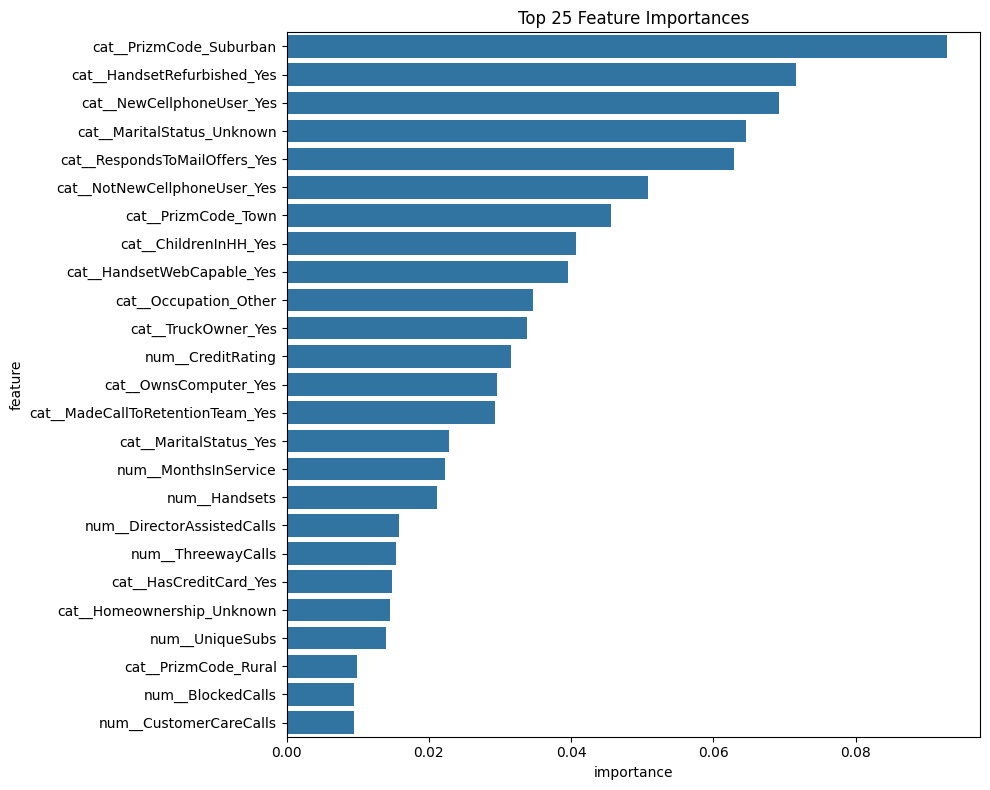

In [221]:
# visualization with a barplot
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df.head(25), x='importance', y='feature')
plt.title('Top 25 Feature Importances')
plt.tight_layout()
plt.show()

These are the top 25 features that are making important contributions to the XGBoost model performance

# Making Predictions with the test data (holdout)

In [223]:
# Since test_data is a dataframe, we need to create X_test and y_test
X_test = test_data.drop(columns=['ServiceArea'])
# best performing model
best_model = best_models['CatBoost'] 

# Pipeline handles preprocessing automatically
y_prob_test = best_model.predict_proba(X_test)[:, 1]
predictions = (y_prob_test >= 0.3).astype(int)

# Attach to the test data
test_data['Churn_Predicted'] = predictions
test_data['Churn_Probability'] = y_prob_test

# showcasing first 15 customers 
test_data.head(20)

,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus,CustomerSupportMonth,OfferAcceptanceRate,FinancialDistressScore,Churn_Predicted,Churn_Probability
0,3000006,57.49,483.0,37.0,0.25,23.0,0.0,532.0,51.0,8.3,1.0,61.3,1.7,0.3,55.3,46.3,6.3,83.7,157.0,9.3,0.0,5.7,56,1,1,MILMIL414,7,6,240,30.0,0.0,No,No,Yes,Yes,Yes,Unknown,Yes,Yes,No,No,No,Yes,0,0,No,Yes,0,5,No,1,No,5,Other,Other,No,0.030357,0.0,True,0,0.102040
1,3000018,55.23,570.0,72.0,0.00,0.0,0.0,38.0,0.0,9.7,0.7,77.0,8.7,0.0,106.3,14.7,0.7,97.3,90.3,10.3,0.0,0.0,57,1,1,NNYSYR315,6,4,434,56.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,Yes,Yes,0,0,Yes,No,0,6,No,2,No,1,Other,Professional,No,0.152632,0.0,True,0,0.244239
2,3000034,97.34,1039.0,50.0,4.95,420.0,0.0,198.0,23.3,12.7,3.0,176.0,11.3,0.3,213.9,103.3,0.3,238.3,192.3,15.7,0.0,4.0,55,1,1,MILMIL414,3,3,700,38.0,24.0,No,No,No,No,No,Unknown,No,No,No,No,No,No,0,0,Yes,No,0,4,No,3,No,3,Suburban,Crafts,Yes,0.205455,0.0,True,0,0.135187
3,3000070,35.59,153.0,30.0,0.00,16.0,0.0,30.0,7.3,2.0,0.7,17.3,0.0,0.0,33.1,8.0,4.7,48.3,7.0,2.7,0.0,0.3,59,3,2,SLCSLC801,6,5,48,46.0,0.0,Yes,No,Yes,Yes,Yes,Known,Yes,Yes,Yes,No,No,Yes,0,0,No,Yes,0,4,No,1,No,1,Other,Other,No,0.000000,0.0,True,0,0.167698
4,3000074,55.27,1213.0,50.0,0.74,0.0,1.3,169.0,1.0,2.7,6.0,43.7,4.3,0.0,490.1,50.7,8.3,189.3,105.0,8.7,0.0,4.3,52,1,1,OKCTUL918,4,4,408,58.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,No,Yes,0,3,No,0,No,1,Suburban,Other,No,0.082692,0.0,True,0,0.049924
5,3000086,60.19,1424.0,56.0,0.25,0.0,0.0,-1134.0,-55.2,23.7,0.0,11.7,0.3,0.0,939.3,7.7,39.0,459.7,174.7,23.7,0.0,5.7,54,1,1,SEAPOR503,13,6,162,50.0,52.0,No,No,Yes,Yes,Yes,Unknown,Yes,Yes,No,No,No,Yes,1,0,No,No,0,5,No,1,Yes,5,Suburban,Other,Yes,0.005556,0.0,True,1,0.349016
6,3000098,25.49,300.0,25.0,0.00,1.0,0.0,-48.0,-0.5,2.0,0.7,14.3,1.0,0.3,77.5,6.3,5.0,45.7,52.3,2.7,0.0,0.3,52,2,2,SLCSLC801,2,2,752,0.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,No,No,0,0,Yes,No,0,6,No,3,No,3,Other,Other,Yes,0.019231,0.0,True,0,0.297537
7,3000110,37.66,972.0,36.0,0.25,5.0,0.0,25.0,-1.7,4.0,0.0,42.7,0.0,0.0,244.6,20.0,8.0,206.3,170.3,4.0,0.0,0.0,58,1,1,PITHOM412,2,2,452,60.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,Yes,1,1,Yes,No,0,1,No,2,Yes,1,Other,Other,No,0.000000,0.5,True,0,0.179085
8,3000246,42.88,406.0,40.0,0.00,54.0,0.0,88.0,3.6,0.7,1.7,27.0,0.0,0.0,47.7,6.3,4.3,93.3,84.3,2.3,0.0,1.7,50,1,1,SANMCA210,2,2,901,50.0,48.0,Yes,Yes,No,Yes,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,5,No,0,No,4,Other,Professional,Yes,0.000000,0.0,False,1,0.368637
9,3000254,342.86,2961.0,140.0,11.14,1445.0,62.3,204.0,6.9,10.0,9.3,113.7,0.0,1.7,871.5,210.7,96.3,732.3,156.0,19.7,2.3,34.3,52,2,2,NSHNSH615,10,7,72,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,Yes,0,0,No,0,No,1,Town,Other,Unknown,0.000000,0.0,True,0,0.131678


In [224]:
# creating a customerID variable
CustomerID = test_data['CustomerID']

# features to work with
results = pd.DataFrame({
    'CustomerID': CustomerID,
    'Churn_Predicted': predictions,
    'Churn_Probability': y_prob_test
})

# Segment by risk level
results['Risk_Level'] = pd.cut(
    results['Churn_Probability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical']
)
print(results.head(30))

    CustomerID  Churn_Predicted  Churn_Probability   Risk_Level
0      3000006                0           0.102040     Low Risk
1      3000018                0           0.244239     Low Risk
2      3000034                0           0.135187     Low Risk
3      3000070                0           0.167698     Low Risk
4      3000074                0           0.049924     Low Risk
5      3000086                1           0.349016  Medium Risk
6      3000098                0           0.297537     Low Risk
7      3000110                0           0.179085     Low Risk
8      3000246                1           0.368637  Medium Risk
9      3000254                0           0.131678     Low Risk
10     3000258                0           0.095773     Low Risk
11     3000274                1           0.336510  Medium Risk
12     3000334                0           0.061259     Low Risk
13     3000338                1           0.335296  Medium Risk
14     3000342                1         